# 🏥 Analisis Sentimen & Pemodelan Topik — Aplikasi Mobile JKN
## Web Mining Final Project — Kelompok 3

---

**Anggota Kelompok:**

- Fariz Naufal Gustoro
- Surya Winaldi Yakin
- Alif Ramdhani Izharulhaq
- Mohammad Aqsha Dwinovryan


---

## 📋 Ringkasan Proyek

Pada proyek ini, kami menyusun pipeline analisis ulasan pengguna aplikasi **Mobile JKN** (BPJS Kesehatan) di Google Play Store secara menyeluruh, mulai dari pengumpulan data mentah hingga penarikan kesimpulan dan. 

Sesuai arahan dosen pembimbing, tahap **Sentiment Analysis** kami fokuskan pada **perbandingan antar model Deep Learning berbasis Transformer**, bukan perbandingan terhadap model Machine Learning klasik (Naive Bayes, SVM), dengan pertimbangan berikut:

- Perbandingan ML klasik vs Deep Learning sudah *well-established* di literatur dan kurang memberikan kontribusi baru.
- Perbandingan antar model Transformer memberikan insight yang lebih relevan dan bernilai secara akademis.
- Pendekatan ini membantu kami menentukan model terbaik secara empiris untuk domain ulasan layanan kesehatan berbahasa Indonesia.

### Model Transformer yang Dibandingkan

| Model | Keterangan |
|-------|------------|
| **IndoBERT** | Model BERT yang dilatih awal (pre-trained) pada korpus Bahasa Indonesia |
| **IndoBERTweet** | BERT yang dioptimalkan untuk teks informal/media sosial Bahasa Indonesia |
| **XLM-RoBERTa** | Model RoBERTa multilingual, umumnya kuat pada kondisi data terbatas (*low-resource*) |
| **mBERT** | BERT multilingual sebagai baseline pembanding |

### Struktur Notebook

Notebook ini kami bagi menjadi tiga bagian besar:

1. **Bagian I — Preprocessing & Topic Modelling**: pengumpulan data, eksplorasi data, pelabelan sentimen berbasis LLM, pengukuran kualitas anotasi, pembersihan teks, dan pemodelan topik dengan BERTopic.
2. **Bagian II — Modelling Sentimen**: pelatihan dan evaluasi empat model Transformer untuk klasifikasi sentimen (Positif/Negatif/Netral), lengkap dengan analisis kesalahan prediksi.
3. **Bagian III — Integrasi Akhir**: menggabungkan hasil topic modelling (Bagian I) dengan model sentimen terbaik (Bagian II) untuk melihat distribusi sentimen per topik, serta menyusun kesimpulan dan rekomendasi produk.

## 📚 Daftar Isi

**Bagian I — Preprocessing & Topic Modelling**
1. [Setup Lingkungan Kerja](#1-setup-lingkungan-kerja)
2. [Pengumpulan Data — Google Play Scraping](#2-pengumpulan-data)
3. [Eksplorasi Data Awal (EDA)](#3-eda)
4. [Pelabelan Sentimen — LLM-Assisted Annotation](#4-labelling)
5. [Inter-Annotator Agreement — Cohen's Kappa](#5-kappa)
6. [Preprocessing Teks](#6-preprocessing)
7. [Topic Modeling — BERTopic](#7-topic-modeling)

**Bagian II — Modelling Sentimen**

8. [Setup Tambahan untuk Deep Learning](#8-setup-dl)
9. [Kontrol Reproducibilitas (Seed)](#9-seed)
10. [Memuat Dataset Hasil Preprocessing](#10-load)
11. [Deduplikasi, Split Data & Leakage Check](#11-split)
12. [Komponen Training: Dataset, Loss, Optimizer](#12-komponen)
13. [Definisi Model & Eksekusi Training](#13-training)
14. [Analisis Kesalahan (Error Analysis)](#14-error)
15. [Visualisasi & Ringkasan Perbandingan Model](#15-viz)

**Bagian III — Integrasi Akhir**

16. [Analisis Sentimen per Topik](#16-sentimen-topik)
17. [Kesimpulan & Rekomendasi](#17-kesimpulan)
18. [Referensi](#18-referensi)

---
# 🅰️ BAGIAN I — PREPROCESSING & TOPIC MODELLING

Pada bagian ini, kami mempersiapkan seluruh data mentah menjadi dataset yang siap dianalisis, sekaligus menggali topik-topik utama yang dibicarakan pengguna dalam ulasan mereka. Keluaran utama bagian ini adalah dataframe `df_clean` (teks yang sudah dibersihkan beserta label sentimen) dan model topik `topic_model`, yang keduanya akan menjadi masukan bagi Bagian II dan Bagian III.

## 1. Setup Lingkungan Kerja <a id="1-setup-lingkungan-kerja"></a>

**Tujuan:** menyiapkan seluruh dependensi (library) yang dibutuhkan di sepanjang notebook — mulai dari scraping, NLP Bahasa Indonesia, deep learning, hingga topic modelling. Sel ini cukup dijalankan sekali di awal sesi; jika runtime di-restart, jalankan kembali sebelum melanjutkan.

Kami menyarankan environment Python 3.8+ dengan GPU (Google Colab Pro atau Kaggle dengan GPU T4/A100) mengingat proses fine-tuning empat model Transformer di Bagian II cukup berat secara komputasi.

In [ ]:
# ============================================================
# CELL 1.1 — INSTALASI LIBRARY
# Jalankan cell ini sekali. Restart runtime setelah selesai.
# ============================================================

!pip install -q google-play-scraper
!pip install -q "transformers>=4.41"
!pip install -q datasets
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn
!pip install -q pandas numpy matplotlib seaborn
!pip install -q bertopic
!pip install -q umap-learn hdbscan
!pip install -q PySastrawi
!pip install -q langdetect
!pip install -q wordcloud
!pip install -q plotly
!pip install -q accelerate
!pip install -q evaluate
!pip install openpyxl

print("✅ Semua library berhasil diinstal!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
✅ Semua library berhasil diinstal!


**Tujuan:** mengimpor seluruh pustaka yang telah terinstal serta menetapkan konfigurasi global yang dipakai konsisten di seluruh notebook — *random seed* untuk reproducibilitas, pemilihan device (CPU/GPU), serta gaya visualisasi (warna, ukuran gambar) yang seragam untuk seluruh grafik.

**Implikasi output:** jika GPU terdeteksi (misalnya Tesla T4), seluruh proses fine-tuning Transformer pada Bagian II akan berjalan jauh lebih cepat dibanding CPU — untuk dataset berskala puluhan ribu ulasan, pelatihan di CPU bisa memakan waktu berjam-jam per model.

In [ ]:
# ============================================================
# CELL 1.2 — IMPORT LIBRARY & KONFIGURASI GLOBAL
# ============================================================

# --- Standard Library ---
import os
import re
import json
import time
import unicodedata
import warnings
import random
from datetime import datetime
from collections import Counter

warnings.filterwarnings('ignore')

# --- Data Processing ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# --- NLP & Text Processing ---
from langdetect import detect, LangDetectException
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# --- Deep Learning (Transformers) ---
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
import evaluate

# --- Topic Modeling ---
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# ============================================================
# KONFIGURASI GLOBAL
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device Configuration ──────────────────────────────────
if torch.cuda.is_available():
    DEVICE   = torch.device('cuda')
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU tersedia!")
    print(f"   Device  : {DEVICE}")
    print(f"   GPU     : {GPU_NAME}")
    print(f"   VRAM    : {GPU_VRAM:.1f} GB")
    print(f"   CUDA    : {torch.version.cuda}")
    if GPU_VRAM < 8:
        print("   ⚠️  VRAM < 8GB — pertimbangkan turunkan batch_size ke 8")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f"✅ Apple MPS tersedia. Device: {DEVICE}")
else:
    DEVICE = torch.device('cpu')
    print("⚠️  Tidak ada GPU — training akan SANGAT LAMBAT di CPU!")
    print("   Disarankan: gunakan Google Colab (Runtime > Change runtime type > T4 GPU)")
print(f"\n🖥️  Device aktif: {DEVICE}")

# Styling Matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('viridis')

# Warna tema project
COLOR_POS  = '#2ecc71'   # Hijau — Positif
COLOR_NEG  = '#e74c3c'   # Merah — Negatif
COLOR_NEU  = '#3498db'   # Biru — Netral
COLORS     = [COLOR_POS, COLOR_NEG, COLOR_NEU]

print("\n✅ Import selesai & konfigurasi global berhasil diterapkan!")

✅ GPU tersedia!
   Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   CUDA    : 12.8

🖥️  Device aktif: cuda

✅ Import selesai & konfigurasi global berhasil diterapkan!


## 2. Pengumpulan Data — Google Play Scraping <a id="2-pengumpulan-data"></a>

**Tujuan:** mengumpulkan ulasan publik aplikasi **Mobile JKN** (`app.bpjs.mobile`) dari Google Play Store menggunakan pustaka `google-play-scraper`. Kami menargetkan 20.000 ulasan berbahasa Indonesia terbaru sebagai basis data mentah.

Atribut yang kami kumpulkan meliputi: `reviewId` (untuk deduplikasi), `userName`, `score` (rating bintang 1–5), `content` (teks ulasan), `thumbsUpCount`, `reviewCreatedVersion`, dan `at` (tanggal ulasan).

> ⚠️ **Catatan:** proses scraping hanya perlu dijalankan sekali. Jika data hasil scraping (atau hasil anotasi LLM) sudah tersedia sebagai berkas `.xlsx`/`.csv`, sel di bagian **2.2** dapat langsung dijalankan untuk memuat data tersebut tanpa mengulang scraping.

In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import time

APP_ID   = 'app.bpjs.mobile'
TARGET   = 20000   # 🎯 target kamu
BATCH    = 2000

all_reviews = []
seen_ids = set()
batch_num = 0

print("🔍 Scraping Mobile JKN...")
print(f"🎯 Target: {TARGET:,} review")
print("-" * 50)

# 🔴 batch pertama
result, continuation_token = reviews(
    APP_ID,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=BATCH
)

while result:
    new_count = 0

    for r in result:
        if r['reviewId'] not in seen_ids:
            all_reviews.append(r)
            seen_ids.add(r['reviewId'])
            new_count += 1

    batch_num += 1

    print(f"Batch {batch_num:03d} | +{new_count} | Total: {len(all_reviews):,}")

    # 🎯 stop kalau sudah target
    if len(all_reviews) >= TARGET:
        print("🎯 Target tercapai!")
        break

    # 🔴 stop kalau data habis
    if not continuation_token:
        print("✅ Data sudah habis dari Google Play")
        break

    time.sleep(2)

    try:
        result, continuation_token = reviews(
            APP_ID,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=BATCH,
            continuation_token=continuation_token
        )
    except Exception as e:
        print("⚠️ Error:", e)
        time.sleep(10)
        continue

# 💾 simpan
df = pd.DataFrame(all_reviews)
df.to_csv('jkn_reviews.csv', index=False)

print("\n📊 FINAL")
print("Total:", len(df))

🔍 Scraping Mobile JKN...
🎯 Target: 20,000 review
--------------------------------------------------
Batch 001 | +2000 | Total: 2,000
Batch 002 | +2000 | Total: 4,000
Batch 003 | +2000 | Total: 6,000
Batch 004 | +2000 | Total: 8,000
Batch 005 | +2000 | Total: 10,000
Batch 006 | +2000 | Total: 12,000
Batch 007 | +2000 | Total: 14,000
Batch 008 | +2000 | Total: 16,000
Batch 009 | +2000 | Total: 18,000
Batch 010 | +2000 | Total: 20,000
🎯 Target tercapai!

📊 FINAL
Total: 20000


**Implikasi output:** proses scraping berhasil mengumpulkan tepat **20.000 ulasan** dalam 10 batch (2.000 ulasan/batch), menandakan target tercapai sebelum data di Google Play habis. Data mentah ini disimpan sebagai `jkn_reviews.csv` sebagai cadangan sebelum proses anotasi sentimen dan pembersihan lebih lanjut.

**Tujuan:** menyimpan data mentah ke format Excel dan mengunduhnya ke perangkat lokal (khusus untuk lingkungan Google Colab) sebagai cadangan sebelum melanjutkan ke tahap anotasi. Sel ini bersifat opsional dan dapat dilewati jika notebook dijalankan di luar Colab.

In [ ]:
df.to_excel('jkn.xlsx', index=False)

from google.colab import files
files.download('jkn.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Tujuan:** memuat data yang telah melalui proses **anotasi sentimen berbasis LLM** (lihat penjelasan metodologi pada Bagian 4). Sel ini merupakan titik masuk utama bagi mereka yang sudah memiliki data hasil anotasi dan ingin melewati proses scraping.

Kami juga melakukan validasi kolom wajib (`content`, `score`, `sentiment`) agar kesalahan struktur data dapat terdeteksi lebih awal, sebelum masuk ke tahap pemrosesan berikutnya.

In [ ]:
# ============================================================
# CELL 2.2 — LOAD DATA HASIL ANOTASI LLM (XLSX ~20K DATA)
#
# ⚡ Jalankan cell ini jika sudah punya file xlsx hasil LLM annotation.
#    Skip seluruh proses scraping di atas.
#
# Dua cara load — pilih salah satu:
#   OPSI A) Upload file baru via Colab file picker
#   OPSI B) Load langsung dari path (jika sudah ada di Drive/Colab)
# ============================================================

import pandas as pd
import io

# ── OPSI A: Upload file via file picker ──────────────────────
# Uncomment blok di bawah jika belum upload:

# from google.colab import files
# print("📤 Upload file Excel hasil anotasi LLM (~20K data)...")
# uploaded_llm = files.upload()
# file_name_llm = list(uploaded_llm.keys())[0]
# df_annotated = pd.read_excel(io.BytesIO(uploaded_llm[file_name_llm]))

# ── OPSI B: Load dari path (lebih cepat jika sudah di Drive) ─
# Ganti path sesuai lokasi file kamu:
FILE_PATH_LLM = 'jkn_sentiment_v3_final (1).xlsx'   # ← ganti nama file di sini

df_annotated = pd.read_excel(FILE_PATH_LLM)

# ── Preview & Validasi ───────────────────────────────────────
print(f"✅ File berhasil di-load!")
print(f"\n📊 Preview:")
print(df_annotated.head(3).to_string())
print(f"\n   Total data   : {len(df_annotated):,} ulasan")
print(f"   Kolom        : {list(df_annotated.columns)}")

# Validasi kolom wajib
required = ['content', 'score', 'sentiment']
missing  = [c for c in required if c not in df_annotated.columns]
if missing:
    print(f"\n⚠️  PERINGATAN: Kolom tidak ditemukan → {missing}")
    print("   Pastikan file mengandung kolom tersebut.")
else:
    print(f"\n✅ Semua kolom wajib tersedia.")
    print(f"\n   Distribusi sentimen LLM:")
    for s, c in df_annotated['sentiment'].value_counts().items():
        print(f"     {s:<10}: {c:,} ({c/len(df_annotated)*100:.1f}%)")


✅ File berhasil di-load!

📊 Preview:
                               reviewId    userName                                                                                           userImage                                                                                                   content  score  thumbsUpCount reviewCreatedVersion                  at                                                                                                                                                                                                                                                                                                               replyContent           repliedAt appVersion sentiment  confidence                                                      reason sentiment_original annotation_changed
0  7f3f76e3-c56c-406f-b47d-df0fd8208720   ARIS BAEE   https://play-lh.googleusercontent.com/a/ACg8ocJUm2IvR5RyR9fN-20p0MkZvylTjagKJfnExucVnsheL3Aljg=mo                         

**Implikasi output:** seluruh 20.000 baris data berhasil dimuat dengan kolom yang lengkap, termasuk kolom hasil anotasi LLM (`sentiment`, `confidence`, `reason`, dll). Ini mengonfirmasi bahwa proses anotasi eksternal (di luar notebook ini) telah berjalan dan siap digunakan.

**Tujuan:** menyaring kolom yang relevan, mengganti nama kolom agar lebih deskriptif (`score` → `rating`, `content` → `review_text`, `at` → `review_date`), serta menghapus duplikasi berdasarkan `reviewId`.

In [ ]:
# ============================================================
# CELL 2.3 — DEDUPLIKASI & SELEKSI KOLOM
# ============================================================

# Kolom yang relevan
COLS_KEEP = ['reviewId', 'userName', 'score', 'content',
             'thumbsUpCount', 'reviewCreatedVersion', 'at', 'sentiment']

df_annotated = df_annotated[COLS_KEEP].copy()

# Rename kolom agar lebih deskriptif
df_annotated.rename(columns={
    'score'   : 'rating',
    'content' : 'review_text',
    'at'      : 'review_date'
}, inplace=True)

# Deduplikasi berdasarkan reviewId
before_dedup = len(df_annotated)
df_annotated.drop_duplicates(subset='reviewId', inplace=True)
after_dedup = len(df_annotated)

# Konversi tipe data
df_annotated['review_date'] = pd.to_datetime(df_annotated['review_date'])
df_annotated['rating']      = df_annotated['rating'].astype(int)

print("📋 Hasil Deduplikasi:")
print(f"   Sebelum : {before_dedup:,} ulasan")
print(f"   Sesudah : {after_dedup:,} ulasan")
print(f"   Dihapus : {before_dedup - after_dedup:,} duplikat")
print(f"\n📅 Rentang Tanggal:")
print(f"   Terlama  : {df_annotated['review_date'].min().strftime('%d %b %Y')}")
print(f"   Terbaru  : {df_annotated['review_date'].max().strftime('%d %b %Y')}")
print(f"\n💾 Tipe Data:")
print(df_annotated.dtypes)

📋 Hasil Deduplikasi:
   Sebelum : 20,000 ulasan
   Sesudah : 20,000 ulasan
   Dihapus : 0 duplikat

📅 Rentang Tanggal:
   Terlama  : 03 Dec 2025
   Terbaru  : 03 May 2026

💾 Tipe Data:
reviewId                        object
userName                        object
rating                           int64
review_text                     object
thumbsUpCount                    int64
reviewCreatedVersion            object
review_date             datetime64[ns]
sentiment                       object
dtype: object


**Implikasi output:** tidak ditemukan duplikat pada data (20.000 sebelum dan sesudah deduplikasi), yang berarti proses scraping sebelumnya sudah cukup baik dalam mencegah data ganda. Rentang tanggal ulasan terbentang dari **Desember 2025 hingga Mei 2026**, mencerminkan data yang relatif baru dan relevan untuk analisis kondisi aplikasi saat ini.

## 3. Eksplorasi Data Awal (EDA) <a id="3-eda"></a>

**Tujuan:** memahami karakteristik dasar data sebelum masuk ke tahap preprocessing — meliputi jumlah data, proporsi *missing values*, distribusi rating, serta statistik panjang teks ulasan.

In [ ]:
# ============================================================
# CELL 3.1 — INFORMASI DASAR DATASET
# ============================================================

print("=" * 60)
print("  INFORMASI DASAR DATASET")
print("=" * 60)
print(f"  Total ulasan         : {len(df_annotated):,}")
print(f"  Missing values       :")
for col in df_annotated.columns:
    mv = df_annotated[col].isna().sum()
    if mv > 0:
        print(f"    {col:<25}: {mv:,} ({mv/len(df_annotated)*100:.1f}%)")

print(f"\n  Distribusi Rating:")
rating_dist = df_annotated['rating'].value_counts().sort_index()
for r, c in rating_dist.items():
    bar = '█' * int(c / len(df_annotated) * 40)
    print(f"    ⭐ {r} : {bar} {c:,} ({c/len(df_annotated)*100:.1f}%)")

print(f"\n  Statistik Panjang Teks (karakter):")
text_len = df_annotated['review_text'].dropna().str.len()
print(f"    Min    : {text_len.min()}")
print(f"    Max    : {text_len.max():,}")
print(f"    Mean   : {text_len.mean():.0f}")
print(f"    Median : {text_len.median():.0f}")

  INFORMASI DASAR DATASET
  Total ulasan         : 20,000
  Missing values       :
    reviewCreatedVersion     : 4,209 (21.0%)

  Distribusi Rating:
    ⭐ 1 : ███████████ 5,612 (28.1%)
    ⭐ 2 : █ 861 (4.3%)
    ⭐ 3 : █ 728 (3.6%)
    ⭐ 4 : █ 943 (4.7%)
    ⭐ 5 : ███████████████████████ 11,856 (59.3%)

  Statistik Panjang Teks (karakter):
    Min    : 1
    Max    : 500
    Mean   : 62
    Median : 30


**Implikasi output:** dari 20.000 ulasan, rating terpolarisasi cukup ekstrem — **59,3% memberi rating 5 bintang**, namun **28,1% memberi rating 1 bintang**, sementara rating 2–4 bintang jumlahnya kecil (di bawah 5% masing-masing). Pola bimodal semacam ini umum dijumpai pada ulasan aplikasi publik: pengguna yang puas atau sangat kecewa lebih terdorong untuk menulis ulasan dibanding pengguna yang merasa biasa saja. Panjang teks ulasan bervariasi dari 1 hingga 500 karakter, dengan median hanya 30 karakter — mengindikasikan sebagian besar ulasan singkat dan padat.

Kolom `reviewCreatedVersion` memiliki 21% nilai kosong, yang perlu diperhatikan jika analisis temporal berdasarkan versi aplikasi ingin dilakukan lebih lanjut.

**Tujuan:** memvisualisasikan sebaran rating, panjang teks, dan jumlah *thumbs up* secara grafis agar pola-pola pada data lebih mudah dipahami secara intuitif dibanding sekadar angka.

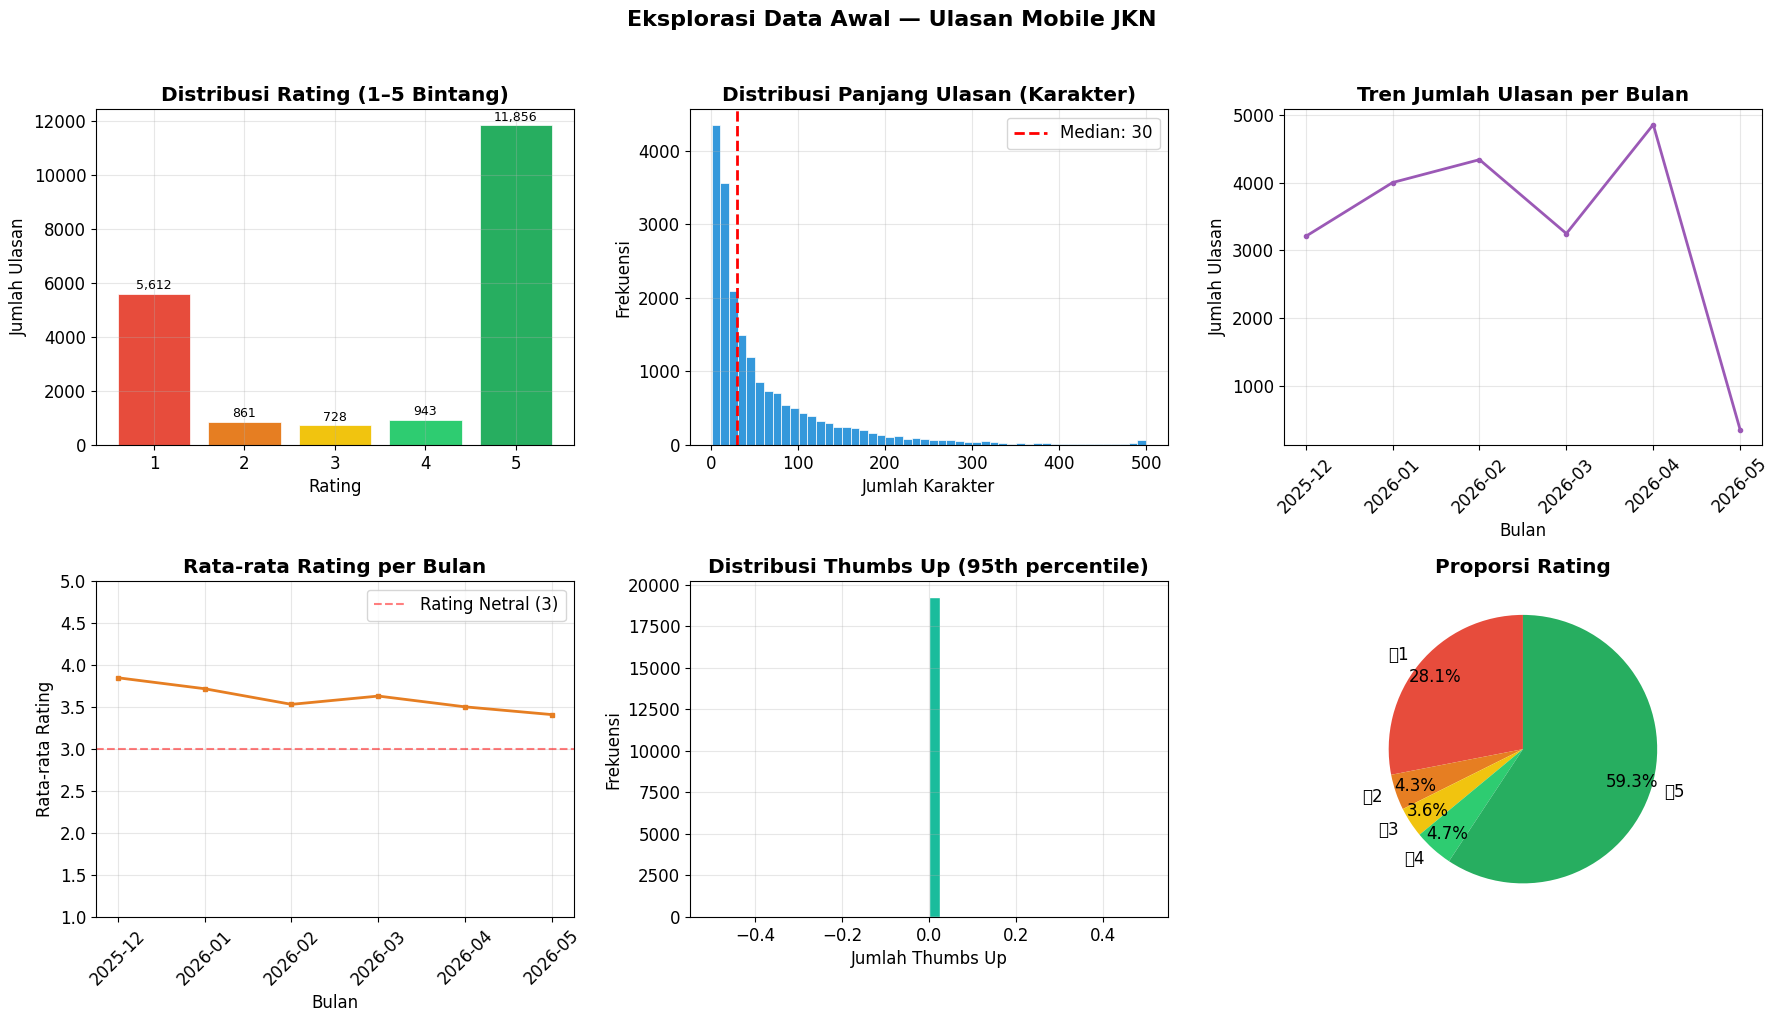

✅ Visualisasi EDA tersimpan sebagai 'eda_overview.png'


In [ ]:
# ============================================================
# CELL 3.2 — VISUALISASI EDA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Eksplorasi Data Awal — Ulasan Mobile JKN',
             fontsize=16, fontweight='bold', y=1.02)

# (1) Distribusi Rating
rating_counts = df_annotated['rating'].value_counts().sort_index()
bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0,0].bar(rating_counts.index, rating_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Distribusi Rating (1–5 Bintang)', fontweight='bold')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Jumlah Ulasan')
for i, (r, c) in enumerate(rating_counts.items()):
    axes[0,0].text(r, c + 50, f'{c:,}', ha='center', va='bottom', fontsize=9)

# (2) Distribusi Panjang Teks
text_len = df_annotated['review_text'].dropna().str.len()
axes[0,1].hist(text_len, bins=50, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0,1].axvline(text_len.median(), color='red', linestyle='--',
                   linewidth=2, label=f'Median: {text_len.median():.0f}')
axes[0,1].set_title('Distribusi Panjang Ulasan (Karakter)', fontweight='bold')
axes[0,1].set_xlabel('Jumlah Karakter')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()

# (3) Tren Ulasan per Bulan
df_annotated['year_month'] = df_annotated['review_date'].dt.to_period('M')
monthly_reviews = df_annotated.groupby('year_month').size()
monthly_reviews.index = monthly_reviews.index.astype(str)
axes[0,2].plot(monthly_reviews.index, monthly_reviews.values,
               color='#9b59b6', linewidth=2, marker='o', markersize=3)
axes[0,2].set_title('Tren Jumlah Ulasan per Bulan', fontweight='bold')
axes[0,2].set_xlabel('Bulan')
axes[0,2].set_ylabel('Jumlah Ulasan')
axes[0,2].tick_params(axis='x', rotation=45)
# Show only every nth label to avoid crowding
n = max(1, len(monthly_reviews) // 12)
axes[0,2].set_xticks(range(0, len(monthly_reviews), n))
axes[0,2].set_xticklabels(monthly_reviews.index[::n], rotation=45)

# (4) Rata-rata Rating per Bulan
monthly_rating = df_annotated.groupby('year_month')['rating'].mean()
monthly_rating.index = monthly_rating.index.astype(str)
axes[1,0].plot(monthly_rating.index, monthly_rating.values,
               color='#e67e22', linewidth=2, marker='s', markersize=3)
axes[1,0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Rating Netral (3)')
axes[1,0].set_ylim(1, 5)
axes[1,0].set_title('Rata-rata Rating per Bulan', fontweight='bold')
axes[1,0].set_xlabel('Bulan')
axes[1,0].set_ylabel('Rata-rata Rating')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_xticks(range(0, len(monthly_rating), n))
axes[1,0].set_xticklabels(monthly_rating.index[::n], rotation=45)
axes[1,0].legend()

# (5) Distribusi ThumbsUp
thumbs = df_annotated['thumbsUpCount'].fillna(0)
thumbs_filtered = thumbs[thumbs <= thumbs.quantile(0.95)]
axes[1,1].hist(thumbs_filtered, bins=40, color='#1abc9c', edgecolor='white')
axes[1,1].set_title('Distribusi Thumbs Up (95th percentile)', fontweight='bold')
axes[1,1].set_xlabel('Jumlah Thumbs Up')
axes[1,1].set_ylabel('Frekuensi')

# (6) Pie Chart Rating
rating_pie = df_annotated['rating'].value_counts().sort_index()
labels_pie = [f'⭐{r}' for r in rating_pie.index]
axes[1,2].pie(rating_pie.values, labels=labels_pie,
               colors=bar_colors, autopct='%1.1f%%',
               startangle=90, pctdistance=0.85)
axes[1,2].set_title('Proporsi Rating', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi EDA tersimpan sebagai 'eda_overview.png'")

**Implikasi output:** visualisasi (tersimpan sebagai `eda_overview.png`) menegaskan temuan pada sel sebelumnya secara visual — proporsi rating 5 bintang dan 1 bintang mendominasi pie chart, sementara distribusi *thumbs up* sangat condong ke nilai rendah (right-skewed), yang wajar mengingat sebagian besar ulasan publik jarang mendapat banyak interaksi \"like\".

## 4. Pelabelan Sentimen — LLM-Assisted Annotation <a id="4-labelling"></a>

Mengingat volume data yang besar (20.000 ulasan), pelabelan sentimen secara manual oleh manusia untuk seluruh data tidak realistis dari segi waktu. Karena itu, kami menggunakan pendekatan **LLM-Assisted Annotation**, mengikuti metodologi yang diperkenalkan oleh Gilardi et al. (2023) dan Alizadeh et al. (2023), yaitu memanfaatkan model bahasa besar (GPT-4o / Claude) untuk melabeli data secara otomatis dengan kualitas yang mendekati anotator manusia.

### Aturan Pelabelan Awal (berbasis rating)

| Rating | Label Sentimen | Alasan |
|--------|----------------|--------|
| 4–5 ⭐ | **Positif** | Rating tinggi umumnya mencerminkan kepuasan |
| 3 ⭐   | **Netral**  | Rating tengah, perlu konfirmasi teks |
| 1–2 ⭐ | **Negatif** | Rating rendah umumnya mencerminkan ketidakpuasan |

Label awal berbasis rating ini kemudian diverifikasi ulang oleh LLM untuk menangkap kasus-kasus di mana teks ulasan tidak konsisten dengan rating yang diberikan (misalnya rating 5 bintang namun isi teks berupa keluhan). Proses anotasi LLM ini dilakukan **di luar notebook** (melalui API LLM terpisah); hasilnya kami muat kembali pada Bagian 2.2 di atas.

> Untuk memastikan kualitas anotasi otomatis ini dapat dipertanggungjawabkan secara akademis, kami mengukur tingkat kesepakatannya dengan anotasi manusia pada bagian berikut.

## 5. Inter-Annotator Agreement — Cohen's Kappa <a id="5-kappa"></a>

**Tujuan:** mengukur seberapa dapat diandalkan label hasil anotasi LLM dengan membandingkannya terhadap label anotasi manual manusia pada sampel data, menggunakan metrik **Cohen's Kappa (κ)**.

Kami memilih Cohen's Kappa alih-alih *accuracy* biasa karena metrik ini memperhitungkan kemungkinan kesepakatan yang terjadi murni karena kebetulan (*chance agreement*), sehingga memberikan gambaran keandalan yang lebih jujur.

### Interpretasi Nilai κ

| Nilai κ | Interpretasi |
|---------|--------------|
| κ < 0.20 | Sangat lemah (*Slight*) |
| 0.21 – 0.40 | Lemah (*Fair*) |
| 0.41 – 0.60 | Cukup (*Moderate*) |
| 0.61 – 0.80 | Kuat (*Substantial*) ✅ |
| 0.81 – 1.00 | Hampir sempurna (*Almost Perfect*) 🎯 |

In [ ]:
# ============================================================
# CELL 5.0 — LOAD FILE ANOTASI MANUSIA
#
# Upload file Excel hasil anotasi manual.
# Kolom yang dibutuhkan: no | reviewId | content | score | sentiment_llm | sentiment_manusia
# ============================================================

import pandas as pd
import io

# ── OPSI A: Upload file baru ──────────────────────────────────
# from google.colab import files
# print("📤 Upload file anotasi manusia...")
# uploaded = files.upload()
# file_name = list(uploaded.keys())[0]
# df_human = pd.read_excel(io.BytesIO(uploaded[file_name]))

# ── OPSI B: Load dari path (lebih cepat) ─────────────────────
FILE_PATH_KAPPA = 'manual label.xlsx'   # ← ganti nama file di sini
df_human = pd.read_excel(FILE_PATH_KAPPA)

# ── Preview & Validasi kolom ─────────────────────────────────
print("📊 Preview file anotasi manusia:")
print(df_human.head(3).to_string())
print(f"\n   Total sampel : {len(df_human):,}")
print(f"   Kolom        : {list(df_human.columns)}")

REQUIRED_KAPPA_COLS = ['sentiment_llm', 'sentiment_manusia']
missing_cols = [c for c in REQUIRED_KAPPA_COLS if c not in df_human.columns]
if missing_cols:
    print(f"\n⚠️  PERINGATAN: Kolom tidak ditemukan → {missing_cols}")
    print("   Cek nama kolom di file Excel kamu.")
else:
    print(f"\n✅ Semua kolom yang dibutuhkan tersedia.")


📊 Preview file anotasi manusia:
   no                              reviewId                                                                                                                                                                                                                                                                                                                                  content  score sentiment_llm sentiment_manusia
0   1  3896ef9f-6796-439d-b60d-6494d247889f                                                                                                                                                                                                                                                            tolong jangan kebanyakan logout pas mau berobat tiba2 logout ribet suka salah      5       negatif           negatif
1   2  8f8e6f4d-3577-4841-8193-5d9d99fd4f8f  aplikasi pemerintah ga guna kalo sistem udah kelewat jaman diperbaikin dana pemerintah tuh buat nge

In [ ]:
# ============================================================
# CELL 5.1 — HITUNG COHEN'S KAPPA
# ============================================================

from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import numpy as np

VALID_LABELS = {'positif', 'negatif', 'netral'}

# Normalisasi label
df_kappa = df_human.copy()
df_kappa['sentiment_llm']      = df_kappa['sentiment_llm'].str.lower().str.strip()
df_kappa['sentiment_manusia']  = df_kappa['sentiment_manusia'].str.lower().str.strip()

# Cek label tidak valid
invalid_mask = ~df_kappa['sentiment_manusia'].isin(VALID_LABELS)
if invalid_mask.any():
    print(f"⚠️  {invalid_mask.sum()} baris dengan label tidak valid (akan dilewati):")
    print(df_kappa[invalid_mask][['content','sentiment_manusia']].head(5))

# Filter hanya baris valid & drop NaN
df_kappa = df_kappa[df_kappa['sentiment_llm'].isin(VALID_LABELS)]
df_kappa = df_kappa[df_kappa['sentiment_manusia'].isin(VALID_LABELS)]
df_kappa = df_kappa.dropna(subset=['sentiment_llm', 'sentiment_manusia'])
n = len(df_kappa)

y_llm   = df_kappa['sentiment_llm'].values
y_human = df_kappa['sentiment_manusia'].values

# Hitung Cohen's Kappa
kappa         = cohen_kappa_score(y_human, y_llm)
agreement_pct = (y_llm == y_human).mean() * 100

def interpret_kappa(k):
    if   k > 0.80: return 'Almost Perfect Agreement ✅✅ (sangat layak publikasi)'
    elif k > 0.60: return 'Substantial Agreement ✅ (layak publikasi)'
    elif k > 0.40: return 'Moderate Agreement ⚠️ (perlu review ulang)'
    elif k > 0.20: return 'Fair Agreement ❌ (anotasi perlu diperbaiki)'
    else:          return 'Slight Agreement ❌❌ (anotasi tidak reliabel)'

print("=" * 60)
print("  HASIL INTER-ANNOTATOR AGREEMENT (Cohen's Kappa)")
print("=" * 60)
print(f"  Total data berlabel  : {n:,}")
print(f"  Simple Agreement     : {agreement_pct:.2f}%")
print(f"  Cohen's Kappa (κ)    : {kappa:.4f}")
print(f"  Interpretasi         : {interpret_kappa(kappa)}")
print("=" * 60)

print("\n📋 Distribusi label:")
print(f"\n  {'Label':<12} {'LLM':>8} {'Manusia':>10} {'Agree %':>10}")
print("  " + "-" * 42)
for label in ['positif', 'negatif', 'netral']:
    n_llm    = (y_llm == label).sum()
    n_human  = (y_human == label).sum()
    n_agree  = ((y_llm == label) & (y_human == label)).sum()
    pct      = n_agree / n_llm * 100 if n_llm > 0 else 0
    print(f"  {label:<12} {n_llm:>8} {n_human:>10} {pct:>9.1f}%")

print("\n  Classification Report (LLM vs Human):")
print(classification_report(y_human, y_llm, target_names=['positif','negatif','netral']))

# Simpan sebagai variabel global
COHEN_KAPPA = kappa
print(f"✅ COHEN_KAPPA = {COHEN_KAPPA:.4f}  (tersimpan, dipakai di cell berikutnya)")


  HASIL INTER-ANNOTATOR AGREEMENT (Cohen's Kappa)
  Total data berlabel  : 1,000
  Simple Agreement     : 91.30%
  Cohen's Kappa (κ)    : 0.8394
  Interpretasi         : Almost Perfect Agreement ✅✅ (sangat layak publikasi)

📋 Distribusi label:

  Label             LLM    Manusia    Agree %
  ------------------------------------------
  positif           555        573      97.8%
  negatif           365        372      93.7%
  netral             80         55      35.0%

  Classification Report (LLM vs Human):
              precision    recall  f1-score   support

     positif       0.94      0.92      0.93       372
     negatif       0.35      0.51      0.41        55
      netral       0.98      0.95      0.96       573

    accuracy                           0.91      1000
   macro avg       0.76      0.79      0.77      1000
weighted avg       0.93      0.91      0.92      1000

✅ COHEN_KAPPA = 0.8394  (tersimpan, dipakai di cell berikutnya)


**Implikasi output:** dari 1.000 sampel yang dibandingkan, kami memperoleh **Cohen's Kappa = 0.8394** (*Almost Perfect Agreement*) dengan tingkat kesepakatan sederhana sebesar 91,3%. Angka ini menunjukkan bahwa label hasil anotasi LLM **cukup layak dijadikan basis pelabelan** untuk seluruh 20.000 data secara akademis.

Namun perlu dicatat satu titik lemah: kelas **netral** memiliki *precision* yang rendah (0.35) meski *recall*-nya tinggi (0.95) dari sisi LLM — artinya LLM cenderung terlalu sering melabeli suatu ulasan sebagai netral padahal manusia melabelinya positif/negatif (tingkat kesepakatan untuk label netral hanya 35%, jauh di bawah positif (97,8%) dan negatif (93,7%)). Implikasinya, hasil klasifikasi model pada kelas netral di Bagian II perlu dibaca dengan lebih hati-hati dibanding kelas positif/negatif.

Saving manual.xlsx to manual (1).xlsx
✅ Semua 1000 baris sudah dilabel dengan benar
   Digunakan untuk kappa: 1000 baris

  HASIL INTER-RATER AGREEMENT
  Total data          : 1000
  Cohen's Kappa (κ)   : 0.8394
  Interpretasi        : Almost Perfect Agreement ✅✅ (sangat layak publikasi)

  Agreement per Label:
  Label          Agree   Disagree    % Agree
  ------------------------------------------
  positif          543         12      97.8%
  negatif          342         23      93.7%
  netral            28         52      35.0%

  Classification Report (LLM vs Human):
              precision    recall  f1-score   support

     positif       0.94      0.92      0.93       372
     negatif       0.35      0.51      0.41        55
      netral       0.98      0.95      0.96       573

    accuracy                           0.91      1000
   macro avg       0.76      0.79      0.77      1000
weighted avg       0.93      0.91      0.92      1000



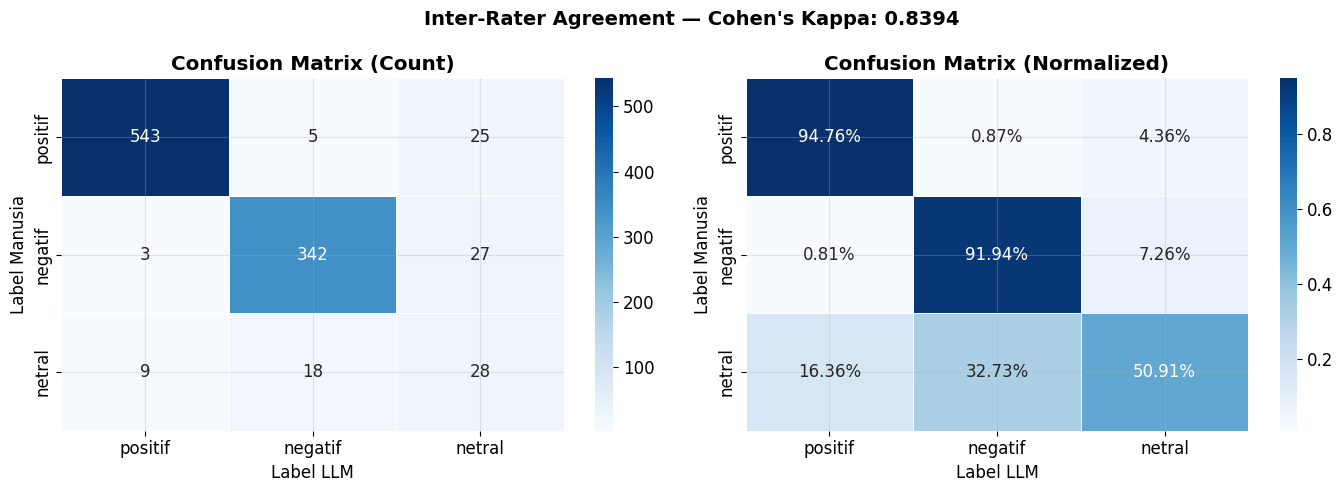


💾 Visualisasi tersimpan: 'cohen_kappa_result.png'
💾 Ringkasan tersimpan: 'kappa_summary.xlsx'


In [ ]:
# ============================================================
# CELL 5.2 — VISUALISASI INTER-ANNOTATOR AGREEMENT
#   Pastikan CELL 5.1 sudah dijalankan terlebih dahulu.
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

labels_order = ['positif', 'negatif', 'netral']
cm      = confusion_matrix(y_human, y_llm, labels=labels_order)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Inter-Rater Agreement — Cohen's Kappa: {COHEN_KAPPA:.4f}\n{interpret_kappa(COHEN_KAPPA)}",
    fontsize=13, fontweight='bold'
)

# Confusion Matrix — raw count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Label LLM (Predicted)')
axes[0].set_ylabel('Label Manusia (Actual)')

# Confusion Matrix — normalized (%)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 13})
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Label LLM (Predicted)')
axes[1].set_ylabel('Label Manusia (Actual)')

plt.tight_layout()
plt.savefig('cohen_kappa_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Visualisasi tersimpan: 'cohen_kappa_result.png'")

# Simpan ringkasan ke Excel
summary = {
    'total_data'       : n,
    'simple_agreement' : round(agreement_pct, 2),
    'cohen_kappa'      : round(COHEN_KAPPA, 4),
    'interpretasi'     : interpret_kappa(COHEN_KAPPA),
}
for label in ['positif', 'negatif', 'netral']:
    n_llm   = (y_llm == label).sum()
    n_agree = ((y_llm == label) & (y_human == label)).sum()
    summary[f'agree_{label}_%'] = round(n_agree / n_llm * 100 if n_llm > 0 else 0, 2)

import pandas as pd
pd.DataFrame([summary]).to_excel('kappa_summary.xlsx', index=False)
print("💾 Ringkasan tersimpan: 'kappa_summary.xlsx'")


**Implikasi output:** confusion matrix (tersimpan sebagai `cohen_kappa_result.png`) memperkuat temuan di atas secara visual — sel-sel kesalahan klasifikasi paling banyak terjadi pada baris/kolom label netral, mengonfirmasi bahwa batas antara "netral" dan "positif/negatif lemah" adalah area yang paling ambigu bagi LLM maupun manusia.

## 6. Preprocessing Teks <a id="6-preprocessing"></a>

**Tujuan:** membersihkan dan menormalisasi teks ulasan Bahasa Indonesia yang sarat kata alay, singkatan tidak baku, karakter berulang, dan emoji, agar layak menjadi masukan model. Kami menyiapkan **dua varian preprocessing** untuk dua kebutuhan berbeda:

- **`preprocess_for_bert`** — preprocessing minimal (lowercase, normalisasi slang, pembersihan karakter aneh) karena model Transformer seperti BERT justru bekerja optimal dengan teks yang masih relatif natural.
- **`preprocess_for_tfidf`** — preprocessing lengkap (ditambah penghapusan stopword & *stemming* menggunakan Sastrawi) untuk kebutuhan topic modelling dan analisis frekuensi kata berbasis TF-IDF.

In [ ]:
# ============================================================
# CELL 6.1 — KAMUS NORMALISASI & KONFIGURASI PREPROCESSING
# ============================================================

# --- Kamus Slang / Kata Alay Indonesia ---
# Sumber: Kamus Alay Indonesia (dikurasi)
SLANG_DICT = {
    # Umum
    'gak'  : 'tidak',  'ga'   : 'tidak',  'nggak': 'tidak',  'ngga' : 'tidak',
    'gk'   : 'tidak',  'tdk'  : 'tidak',  'tdk'  : 'tidak',  'krn'  : 'karena',
    'karna': 'karena', 'kalo' : 'kalau',  'kl'   : 'kalau',  'udh'  : 'sudah',
    'udah' : 'sudah',  'sdh'  : 'sudah',  'blm'  : 'belum',  'blom' : 'belum',
    'sm'   : 'sama',   'ama'  : 'sama',   'bgt'  : 'banget', 'bkn'  : 'bukan',
    'emg'  : 'memang', 'emang': 'memang', 'tp'   : 'tapi',   'tapi' : 'tetapi',
    'dgn'  : 'dengan', 'dg'   : 'dengan', 'yg'   : 'yang',   'utk'  : 'untuk',
    'org'  : 'orang',  'msh'  : 'masih',  'masi' : 'masih',  'lg'   : 'lagi',
    'lgi'  : 'lagi',   'bs'   : 'bisa',   'bsa'  : 'bisa',   'hrs'  : 'harus',
    'skrg' : 'sekarang','skrang':'sekarang','jg'  : 'juga',   'jga'  : 'juga',
    'sy'   : 'saya',   'aq'   : 'saya',   'ak'   : 'saya',   'gue'  : 'saya',
    'gw'   : 'saya',   'lo'   : 'kamu',   'lu'   : 'kamu',   'km'   : 'kamu',
    'ny'   : 'nya',    'nih'  : 'ini',    'tuh'  : 'itu',    'sih'  : '',
    'deh'  : '',       'kok'  : '',       'dong' : '',
    # Aplikasi Mobile JKN spesifik
    'bpjs' : 'bpjs',  'jkn'  : 'jkn',    'faskes': 'fasilitas kesehatan',
    'puskesmas':'puskesmas','rs':'rumah sakit','nakes':'tenaga kesehatan',
    'antri': 'antre', 'ngantri': 'mengantre', 'login': 'masuk',
    'update': 'perbarui', 'error': 'kesalahan', 'bug': 'bug',
    'loading': 'memuat', 'force close': 'keluar paksa',
}

# --- Inisialisasi Sastrawi (Stemmer & Stopword) ---
stemmer_factory  = StemmerFactory()
STEMMER          = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
STOPWORDS        = set(stopword_factory.get_stop_words())

# Tambahkan custom stopwords yang tidak informatif
CUSTOM_STOPWORDS = {
    'aplikasi', 'app', 'mobile', 'jkn', 'bpjs', 'versi',
    'update', 'tolong', 'mohon', 'terima', 'kasih', 'terimakasih',
    'makasih', 'semoga', 'harap', 'coba'
}
STOPWORDS_CLASSIFICATION = STOPWORDS | CUSTOM_STOPWORDS
# CATATAN: Stopword removal hanya untuk analisis frekuensi/TF-IDF,
# BUKAN untuk input model Transformer (BERT membutuhkan teks utuh)

print("✅ Konfigurasi preprocessing selesai!")
print(f"   Total kata slang dalam kamus : {len(SLANG_DICT):,}")
print(f"   Total stopwords (Sastrawi)   : {len(STOPWORDS):,}")
print(f"   Total stopwords (custom)     : {len(CUSTOM_STOPWORDS):,}")

✅ Konfigurasi preprocessing selesai!
   Total kata slang dalam kamus : 68
   Total stopwords (Sastrawi)   : 809
   Total stopwords (custom)     : 16


**Implikasi output:** kamus normalisasi slang berisi 68 pasangan kata (mis. "gak"→"tidak", "bgt"→"banget"), dilengkapi 809 stopword baku dari Sastrawi dan 16 stopword tambahan yang spesifik untuk domain aplikasi ini (mis. "aplikasi", "bpjs", "jkn") agar tidak mendominasi hasil topic modelling nantinya.

In [ ]:
# ============================================================
# CELL 6.2 — FUNGSI PREPROCESSING
# ============================================================

def remove_urls_html(text: str) -> str:
    """Hapus URL dan tag HTML dari teks."""
    # Hapus URL (http, https, www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Hapus tag HTML
    text = re.sub(r'<[^>]+>', '', text)
    return text


def remove_strange_chars(text: str) -> str:
    """Hapus karakter aneh/tidak relevan, pertahankan karakter dasar + emoji."""
    # Normalisasi unicode
    text = unicodedata.normalize('NFKC', text)
    # Hapus karakter kontrol (kecuali newline dan spasi)
    text = re.sub(r'[\x00-\x08\x0b-\x0c\x0e-\x1f\x7f]', '', text)
    # Hapus karakter berulang lebih dari 3x (mis: "bagussss" → "bagus")
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    return text


def normalize_case(text: str) -> str:
    """Ubah teks ke huruf kecil."""
    return text.lower()


def normalize_slang(text: str, slang_dict: dict) -> str:
    """Normalisasi kata slang dan singkatan menggunakan kamus."""
    tokens = text.split()
    normalized = [slang_dict.get(token, token) for token in tokens]
    return ' '.join(t for t in normalized if t)  # Filter token kosong


def remove_punctuation_numbers(text: str) -> str:
    """Hapus tanda baca dan angka (untuk NLP klasik, bukan BERT)."""
    text = re.sub(r'[^\w\s]', ' ', text)  # Hapus tanda baca
    text = re.sub(r'\d+', '', text)        # Hapus angka
    text = re.sub(r'\s+', ' ', text)       # Normalisasi spasi
    return text.strip()


def remove_stopwords(text: str, stopwords: set) -> str:
    """Hapus stopwords dari teks."""
    tokens = text.split()
    return ' '.join(t for t in tokens if t not in stopwords)


def stem_text(text: str, stemmer) -> str:
    """Stemming menggunakan PySastrawi."""
    return stemmer.stem(text)


def is_indonesian(text: str) -> bool:
    """Deteksi apakah teks berbahasa Indonesia."""
    try:
        return detect(text) in ['id', 'ms']  # Indonesia atau Melayu
    except LangDetectException:
        return True  # Default: anggap Indonesia jika tidak bisa dideteksi


def preprocess_for_bert(text: str) -> str:
    """
    Preprocessing MINIMAL untuk input model Transformer (BERT).
    BERT membutuhkan teks yang masih natural — tidak perlu stemming/stopword removal.

    Pipeline:
    1. Hapus URL & HTML
    2. Hapus karakter aneh
    3. Normalisasi huruf (lowercase)
    4. Normalisasi slang
    5. Normalisasi spasi
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = remove_urls_html(text)
    text = remove_strange_chars(text)
    text = normalize_case(text)
    text = normalize_slang(text, SLANG_DICT)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_for_tfidf(text: str) -> str:
    """
    Preprocessing LENGKAP untuk TF-IDF / analisis frekuensi.
    Termasuk stemming dan stopword removal.
    (Digunakan untuk Topic Modeling dan analisis kata)

    Pipeline:
    1. Hapus URL & HTML
    2. Hapus karakter aneh
    3. Normalisasi huruf
    4. Normalisasi slang
    5. Hapus tanda baca & angka
    6. Hapus stopwords
    7. Stemming (Sastrawi)
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = remove_urls_html(text)
    text = remove_strange_chars(text)
    text = normalize_case(text)
    text = normalize_slang(text, SLANG_DICT)
    text = remove_punctuation_numbers(text)
    text = remove_stopwords(text, STOPWORDS_CLASSIFICATION)
    text = stem_text(text, STEMMER)
    return text


print("✅ Fungsi preprocessing berhasil didefinisikan!")
print("\n🧪 Demo preprocessing:")
demo_texts = [
    "Apk ini bgus bgt!! Loading nya cepet, gak ada bug. Mantap deh BPJS JKN 👍",
    "Aplikasi error mulu, gak bisa login sama sekali. Tolong difix ya!",
    "Biasa aja sih, fiturnya lengkap tp kadang lambat."
]
for t in demo_texts:
    print(f"\n  Original  : {t[:60]}...")
    print(f"  BERT prep : {preprocess_for_bert(t)[:60]}...")
    print(f"  TFIDF prep: {preprocess_for_tfidf(t)[:60]}...")

✅ Fungsi preprocessing berhasil didefinisikan!

🧪 Demo preprocessing:

  Original  : Apk ini bgus bgt!! Loading nya cepet, gak ada bug. Mantap de...
  BERT prep : apk ini bgus bgt!! memuat nya cepet, tidak ada bug. mantap b...
  TFIDF prep: apk bgus bgt muat cepet bug mantap...

  Original  : Aplikasi error mulu, gak bisa login sama sekali. Tolong difi...
  BERT prep : aplikasi kesalahan mulu, tidak bisa masuk sama sekali. tolon...
  TFIDF prep: salah mulu difix...

  Original  : Biasa aja sih, fiturnya lengkap tp kadang lambat....
  BERT prep : biasa aja sih, fiturnya lengkap tapi kadang lambat....
  TFIDF prep: aja sih fiturnya lengkap kadang lambat...


**Implikasi output:** contoh demo di atas menunjukkan perbedaan kedua fungsi preprocessing secara nyata — `preprocess_for_bert` mempertahankan struktur kalimat (mengganti "bgus bgt" menjadi "bagus banget" dst.), sementara `preprocess_for_tfidf` menghasilkan teks yang jauh lebih ringkas berupa kata-kata inti setelah stopword removal dan stemming (mis. "aplikasi error mulu, gak bisa login..." menjadi "salah mulu difix").

In [ ]:
# ============================================================
# CELL 6.3 — TERAPKAN PREPROCESSING KE DATASET
# ============================================================

print("⚙️  Menerapkan preprocessing ke dataset...")
print("   (Proses ini mungkin memakan beberapa menit)")

df_clean = df_annotated.copy()  # df_annotated sudah diupdate di Section 5

# --- Step 1: Hapus missing values ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['review_text'].notna()]
df_clean = df_clean[df_clean['review_text'].str.strip() != '']
print(f"   [1/5] Hapus missing   : {n_before - len(df_clean)} dihapus")

# --- Step 2: Filter bahasa Indonesia ---
n_before = len(df_clean)
# Note: langdetect lambat untuk dataset besar, gunakan sampling atau skip jika perlu
# df_clean['is_id'] = df_clean['review_text'].apply(is_indonesian)
# df_clean = df_clean[df_clean['is_id']]
print(f"   [2/5] Filter bahasa   : (skipped untuk efisiensi — sudah filter lang='id' saat scraping)")

# --- Step 3: Preprocessing untuk BERT ---
df_clean['text_bert'] = df_clean['review_text'].apply(preprocess_for_bert)
print(f"   [3/5] Preprocessing BERT : ✅")

# --- Step 4: Preprocessing untuk TF-IDF / Topic Modeling ---
df_clean['text_tfidf'] = df_clean['review_text'].apply(preprocess_for_tfidf)
print(f"   [4/5] Preprocessing TF-IDF : ✅")

# --- Step 5: Filter teks kosong setelah preprocessing ---
n_before = len(df_clean)
df_clean = df_clean[
    (df_clean['text_bert'].str.strip() != '') &
    (df_clean['text_tfidf'].str.strip() != '')
]
print(f"   [5/5] Filter post-prep : {n_before - len(df_clean)} dihapus")

# Encode label sentimen
LABEL_MAP     = {'positif': 0, 'negatif': 1, 'netral': 2}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
df_clean['label_id'] = df_clean['sentiment'].map(LABEL_MAP)

# Simpan dataset bersih
df_clean.to_csv('jkn_reviews_clean.csv', index=False)

print(f"\n📊 Dataset setelah preprocessing:")
print(f"   Total ulasan  : {len(df_clean):,}")
print(f"\n   Distribusi sentimen:")
for s, c in df_clean['sentiment'].value_counts().items():
    print(f"   {s.capitalize():<12}: {c:,} ({c/len(df_clean)*100:.1f}%)")

⚙️  Menerapkan preprocessing ke dataset...
   (Proses ini mungkin memakan beberapa menit)
   [1/5] Hapus missing   : 0 dihapus
   [2/5] Filter bahasa   : (skipped untuk efisiensi — sudah filter lang='id' saat scraping)
   [3/5] Preprocessing BERT : ✅
   [4/5] Preprocessing TF-IDF : ✅
   [5/5] Filter post-prep : 694 dihapus

📊 Dataset setelah preprocessing:
   Total ulasan  : 19,306

   Distribusi sentimen:
   Positif     : 10,491 (54.3%)
   Negatif     : 7,268 (37.6%)
   Netral      : 1,547 (8.0%)


**Implikasi output:** setelah preprocessing, dataset bersih (`df_clean`, disimpan sebagai `jkn_reviews_clean.csv`) berisi **19.306 ulasan** (694 baris terhapus karena teks kosong setelah dibersihkan). Distribusi sentimen pada data bersih adalah **Positif 54,3%, Negatif 37,6%, Netral hanya 8,0%** — menunjukkan **ketidakseimbangan kelas (class imbalance)** yang cukup signifikan, khususnya pada kelas netral yang jumlahnya jauh lebih sedikit. Temuan ini penting: pada Bagian II, kami menangani ketidakseimbangan ini secara eksplisit menggunakan *Focal Loss* dengan *class weighting*, alih-alih *cross-entropy* biasa.

## 7. Topic Modeling — BERTopic <a id="7-topic-modeling"></a>

**Tujuan:** mengidentifikasi topik-topik utama yang dibicarakan pengguna dalam ulasan mereka menggunakan **BERTopic**, yang menggabungkan beberapa teknik:

- **Sentence Transformers** (IndoBERT) — merepresentasikan makna semantik tiap ulasan sebagai vektor.
- **UMAP** — mereduksi dimensi vektor tersebut agar proses clustering lebih efisien.
- **HDBSCAN** — mengelompokkan ulasan-ulasan bermakna serupa ke dalam klaster (topik).
- **c-TF-IDF** — mengekstraksi kata-kata paling representatif dari tiap klaster.

In [ ]:
# ============================================================
# CELL 11.1 — SETUP DAN KONFIGURASI BERTOPIC
# ============================================================

print("⚙️  Menyiapkan BERTopic pipeline...")

# --- Embedding Model (IndoBERT via SentenceTransformers) ---
# Gunakan IndoBERT yang sudah di-fine-tune untuk sentence similarity
EMBEDDING_MODEL_ID = 'firqaaa/indo-sentence-bert-base'
# Alternatif: 'LazarusNLP/all-indo-e5-small-v4' (lebih ringan)

print(f"📥 Memuat sentence embedding model: {EMBEDDING_MODEL_ID}")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_ID)

# --- UMAP: Reduksi Dimensi ---
umap_model = UMAP(
    n_neighbors=15,      # Jumlah tetangga lokal
    n_components=5,      # Dimensi output (untuk HDBSCAN)
    min_dist=0.0,        # Jarak minimum antar titik
    metric='cosine',     # Metrik jarak
    random_state=SEED,
    low_memory=True
)

# --- HDBSCAN: Clustering ---
hdbscan_model = HDBSCAN(
    min_cluster_size=50,   # Minimum ukuran cluster (sesuaikan dengan ukuran data)
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# --- Inisialisasi BERTopic ---
topic_model = BERTopic(
    embedding_model  = embedding_model,
    umap_model       = umap_model,
    hdbscan_model    = hdbscan_model,
    top_n_words      = 10,      # Kata per topik
    nr_topics        = 'auto',  # Auto-detect jumlah topik
    calculate_probabilities = True,
    verbose          = True
)

print("✅ BERTopic pipeline berhasil dikonfigurasi!")

⚙️  Menyiapkan BERTopic pipeline...
📥 Memuat sentence embedding model: firqaaa/indo-sentence-bert-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: firqaaa/indo-sentence-bert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERTopic pipeline berhasil dikonfigurasi!


**Implikasi output:** pipeline BERTopic berhasil dikonfigurasi menggunakan model *sentence embedding* IndoBERT (`firqaaa/indo-sentence-bert-base`), yang dipilih karena representasi semantik kalimat Bahasa Indonesia lebih relevan dibanding model *general-purpose* multilingual untuk kebutuhan clustering topik.

In [ ]:
# ============================================================
# CELL 11.2 — FIT BERTOPIC MODEL
#
# Menggunakan kolom text_tfidf (sudah dipreprocess lengkap)
# untuk topic modeling yang lebih bersih.
# ============================================================

# Gunakan semua ulasan (tidak hanya sample) untuk topic modeling
topic_texts = df_clean['text_bert'].dropna().tolist()  # Teks minimal preprocessing

print(f"🔍 Memulai BERTopic fitting pada {len(topic_texts):,} ulasan...")
print("   (Proses ini mungkin memakan 10-30 menit tergantung ukuran data)")

start_time = time.time()

topics, probs = topic_model.fit_transform(topic_texts)

elapsed = time.time() - start_time
print(f"\n⏱️  BERTopic selesai dalam {elapsed/60:.1f} menit")

# Informasi topik
topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])

print(f"\n📊 Hasil Topic Modeling:")
print(f"   Total topik ditemukan : {n_topics}")
print(f"   Outlier (Topic -1)    : {(np.array(topics) == -1).sum():,} ulasan")
print(f"\n   Top 10 Topik:")
print(topic_info[topic_info['Topic'] != -1].head(10)[['Topic', 'Count', 'Name']].to_string(index=False))

2026-05-07 10:18:39,825 - BERTopic - Embedding - Transforming documents to embeddings.


🔍 Memulai BERTopic fitting pada 19,306 ulasan...
   (Proses ini mungkin memakan 10-30 menit tergantung ukuran data)


Batches:   0%|          | 0/604 [00:00<?, ?it/s]

2026-05-07 10:19:10,473 - BERTopic - Embedding - Completed ✓
2026-05-07 10:19:10,474 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 10:19:47,806 - BERTopic - Dimensionality - Completed ✓
2026-05-07 10:19:47,809 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 10:19:53,746 - BERTopic - Cluster - Completed ✓
2026-05-07 10:19:53,747 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-07 10:19:53,957 - BERTopic - Representation - Completed ✓
2026-05-07 10:19:53,958 - BERTopic - Topic reduction - Reducing number of topics
2026-05-07 10:19:53,998 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 10:19:54,192 - BERTopic - Representation - Completed ✓
2026-05-07 10:19:54,196 - BERTopic - Topic reduction - Reduced number of topics from 90 to 53



⏱️  BERTopic selesai dalam 1.2 menit

📊 Hasil Topic Modeling:
   Total topik ditemukan : 52
   Outlier (Topic -1)    : 5,017 ulasan

   Top 10 Topik:
 Topic  Count                                Name
     0   1759           0_kode_otp_sms_verifikasi
     1   1141 1_membantu_sangat_bermanfaat_sekali
     2    921       2_bagus_sangat_josjis_lumayan
     3    904  3_kesehatan_bpjs_fasilitas_berobat
     4    773       4_sakit_berobat_rumah_rujukan
     5    669                 5_ok_oke_sippp_okey
     6    601   6_mantap_mantapp_mantappp_mantaps
     7    550       7_mudah_digunakan_gunakan_dan
     8    521           8_bgus_mantul_mantaap_jos
     9    511   9_aplikasi_sering_log_aplikasinya


**Implikasi output:** BERTopic berhasil mengidentifikasi **52 topik** dari 19.306 ulasan (setelah reduksi otomatis dari 90 menjadi 53 topik kandidat) hanya dalam **1,2 menit** — cukup cepat berkat efisiensi UMAP+HDBSCAN. Sebanyak **5.017 ulasan (±26%)** tergolong *outlier* (Topic -1), yaitu ulasan yang tidak cukup mirip dengan klaster manapun — proporsi ini tergolong wajar untuk data ulasan aplikasi yang sangat beragam topiknya, namun tetap perlu diperhatikan karena berarti seperempat data tidak masuk kategori topik tertentu.

Topik dengan volume terbesar adalah seputar **kode OTP/verifikasi SMS** (1.759 ulasan) — mengindikasikan bahwa isu autentikasi merupakan pain point yang paling sering dibicarakan pengguna.

In [ ]:
# ============================================================
# CELL 11.3 — LABELING TOPIK SECARA MANUAL
#
# Berikan label deskriptif pada setiap topik berdasarkan
# kata-kata yang paling representatif.
# ============================================================

print("📋 Representasi Kata per Topik (untuk labeling manual):")
print("=" * 70)

topic_word_repr = {}
for topic_id in sorted(topic_model.get_topics().keys()):
    if topic_id == -1:
        continue
    words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
    topic_word_repr[topic_id] = words
    count = (np.array(topics) == topic_id).sum()
    print(f"   Topik {topic_id:2d} ({count:5,} ulasan): {', '.join(words[:10])}")


print(f"\n✅ Sesuaikan TOPIC_LABELS di atas berdasarkan kata representatif aktual!")

📋 Representasi Kata per Topik (untuk labeling manual):
   Topik  0 (1,759 ulasan): kode, otp, sms, verifikasi, nomor, tidak, masuk, sudah, nik, bisa
   Topik  1 (1,141 ulasan): membantu, sangat, bermanfaat, sekali, bagus, dan, berguna, baik, memudahkan, mempermudah
   Topik  2 (  921 ulasan): bagus, sangat, josjis, lumayan, baik, cukup, baguss, ok, hebat, mantap
   Topik  3 (  904 ulasan): kesehatan, bpjs, fasilitas, berobat, untuk, dalam, pelayanan, memudahkan, sangat, membantu
   Topik  4 (  773 ulasan): sakit, berobat, rumah, rujukan, antrian, mau, ke, daftar, kesehatan, fasilitas
   Topik  5 (  669 ulasan): ok, oke, sippp, okey, okeh, okee, okay, lah, sip, baik
   Topik  6 (  601 ulasan): mantap, mantapp, mantappp, mantaps, ok, jiwa, pokok, bos, oke, betul
   Topik  7 (  550 ulasan): mudah, digunakan, gunakan, dan, simple, sangat, lebih, simpel, membantu, gampang
   Topik  8 (  521 ulasan): bgus, mantul, mantaap, jos, apk, mntap, jis, mantaf, siip, josss
   Topik  9 (  511 ulasan):

**Implikasi output:** representasi kata-kata kunci per topik di atas menjadi dasar bagi kami untuk memberi label deskriptif pada tiap topik secara manual (misalnya Topik 0 → "OTP & Verifikasi", Topik 4 → "Rujukan Rumah Sakit"). Beberapa topik teratas justru berisi kata-kata pujian umum (Topik 1 "membantu, bermanfaat", Topik 2 "bagus, mantap") — mencerminkan proporsi ulasan positif yang cukup besar sejalan dengan temuan preprocessing sebelumnya.

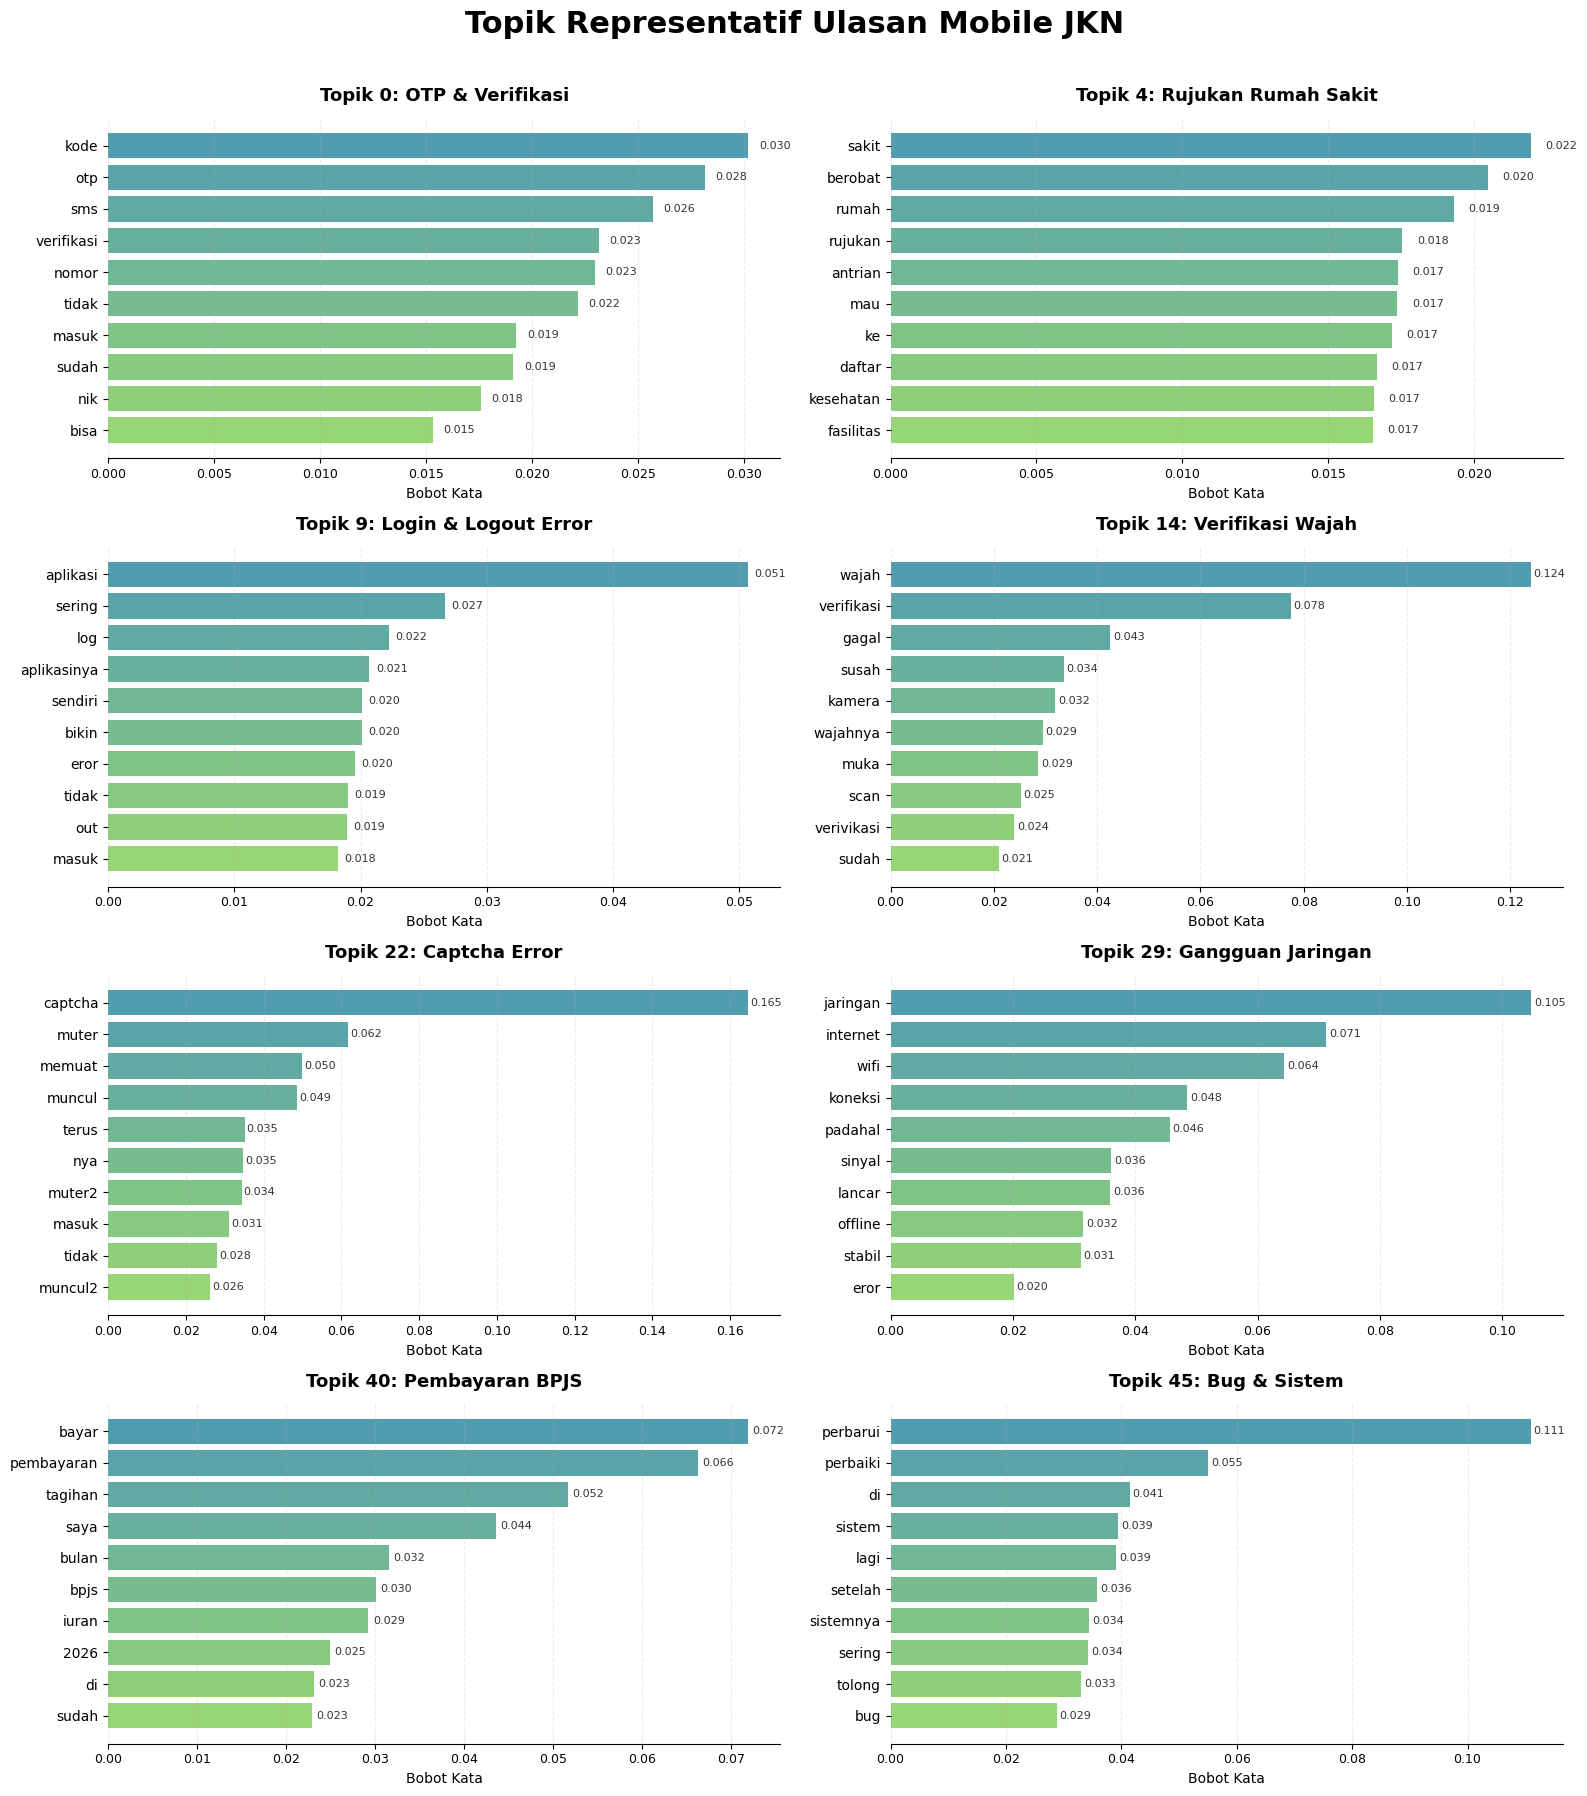

✅ Saved: topic_visualization_per_graph_gradient.png


In [ ]:
# ============================================================
# VISUALISASI TOPIK — GRADIENT PER GRAFIK
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

REPRESENTATIVE_TOPICS = {
    0:  'OTP & Verifikasi',
    4:  'Rujukan Rumah Sakit',
    9:  'Login & Logout Error',
    14: 'Verifikasi Wajah',
    22: 'Captcha Error',
    29: 'Gangguan Jaringan',
    40: 'Pembayaran BPJS',
    45: 'Bug & Sistem'
}

# ============================================================
# CUSTOM GRADIENT
# ============================================================

START_COLOR = "#90d46c"
END_COLOR   = "#4898ab"

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    [START_COLOR, END_COLOR]
)

# ============================================================
# FIGURE
# ============================================================

plt.style.use('default')

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 18)
)

fig.suptitle(
    'Topik Representatif Ulasan Mobile JKN',
    fontsize=22,
    fontweight='bold',
    y=0.995
)

axes = axes.flatten()

# ============================================================
# PLOT
# ============================================================

for ax, (topic_id, topic_label) in zip(
    axes,
    REPRESENTATIVE_TOPICS.items()
):

    # Ambil top words
    topic_words = topic_model.get_topic(topic_id)[:10]

    words  = [w for w, _ in topic_words]
    scores = [s for _, s in topic_words]

    # Reverse supaya terbesar di atas
    words.reverse()
    scores.reverse()

    # Gradient per bar
    gradient_colors = [
        custom_cmap(i)
        for i in np.linspace(0, 1, len(words))
    ]

    # Plot
    bars = ax.barh(
        words,
        scores,
        color=gradient_colors,
        edgecolor='none',
        alpha=0.95
    )

    # Title
    ax.set_title(
        f"Topik {topic_id}: {topic_label}",
        fontsize=13,
        fontweight='bold',
        pad=12
    )

    # Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.25
    )

    # Value labels
    for bar in bars:

        width = bar.get_width()

        ax.text(
            width + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f"{width:.3f}",
            va='center',
            fontsize=8,
            color='#333333'
        )

    # Tick style
    ax.tick_params(
        axis='y',
        labelsize=10
    )

    ax.tick_params(
        axis='x',
        labelsize=9
    )

    ax.set_xlabel(
        'Bobot Kata',
        fontsize=10
    )

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.985])

plt.savefig(
    'topic_visualization_per_graph_gradient.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: topic_visualization_per_graph_gradient.png")

**Implikasi output:** visualisasi delapan topik representatif (tersimpan sebagai `topic_visualization_per_graph_gradient.png`) menunjukkan bobot kata (c-TF-IDF) tiap topik — memudahkan pembaca non-teknis memahami "isi" tiap topik hanya dari kata-kata yang paling menonjol, tanpa perlu membaca ulasan mentahnya satu per satu.

> ### 🔧 Catatan Perbaikan — Penyelarasan Nama Variabel
>
> Pada notebook asli, sel-sel di bagian akhir (analisis sentimen per topik dan kesimpulan) memanggil variabel `TOPIC_LABELS`, padahal yang didefinisikan pada tahap pelabelan topik di atas adalah `REPRESENTATIVE_TOPICS`. Akibatnya, pada berkas asli sel tersebut gagal dijalankan (`NameError`/`KeyError`). Kami menambahkan sel kecil berikut untuk menyelaraskan penamaan tersebut, sehingga pipeline dapat berjalan tanpa terputus.

In [ ]:
# ============================================================
# SEL TAMBAHAN (BRIDGING) — PENYELARASAN NAMA VARIABEL
# ============================================================
# 'TOPIC_LABELS' dipakai di sel-sel berikutnya (analisis sentimen
# per topik & ringkasan akhir), namun pada notebook asli hanya
# 'REPRESENTATIVE_TOPICS' yang didefinisikan pada tahap pelabelan
# topik. Baris berikut menyamakan keduanya.
TOPIC_LABELS = REPRESENTATIVE_TOPICS
print(f"✅ TOPIC_LABELS tersedia ({len(TOPIC_LABELS)} topik berlabel manual)")

---

**Ringkasan Bagian I:** kami telah memperoleh `df_clean` — 19.306 ulasan bersih lengkap dengan label sentimen (`sentiment`, `label_id`) dan dua varian teks preprocessing (`text_bert`, `text_tfidf`) — serta `topic_model` beserta 52 topik yang telah teridentifikasi. Kedua keluaran ini menjadi fondasi bagi **Bagian II**, di mana kami akan melatih model klasifikasi sentimen berbasis Transformer di atas `df_clean`.

---
# 🅱️ BAGIAN II — MODELLING SENTIMEN

Pada bagian ini, kami melatih dan membandingkan empat model Transformer (IndoBERT, IndoBERTweet, XLM-RoBERTa, mBERT) untuk tugas klasifikasi sentimen tiga kelas (Positif/Negatif/Netral) di atas dataset `df_clean` yang telah dipersiapkan pada Bagian I.

## 8. Setup Tambahan untuk Deep Learning <a id="8-setup-dl"></a>

**Tujuan:** mengimpor modul-modul tambahan yang secara spesifik dibutuhkan untuk proses fine-tuning manual (bukan menggunakan `Trainer` bawaan HuggingFace), seperti `torch.nn`/`torch.nn.functional` untuk implementasi Focal Loss kustom, `AdamW` beserta *learning-rate scheduler*, dan `tqdm` untuk progress bar training.

> **Catatan:** instalasi pustaka (`transformers`, `accelerate`, `scikit-learn`, `seaborn`, `matplotlib`) pada notebook aslinya diulang di sini. Karena seluruh pustaka tersebut telah terpasang pada **Setup Lingkungan Kerja (Bagian 1)**, sel instalasi ulang tersebut kami hilangkan agar notebook lebih ringkas — namun jika Bagian II dijalankan pada sesi/runtime yang benar-benar baru (terpisah dari Bagian I), instalasi ulang tersebut perlu dilakukan kembali.

In [ ]:
# ===========================================================
# CELL 1: IMPORTS
# ===========================================================
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 9. Kontrol Reproducibilitas (Seed) <a id="9-seed"></a>

**Tujuan:** mengunci seluruh sumber keacakan (Python `random`, NumPy, PyTorch, cuDNN) pada satu nilai *seed* tetap, agar proses training dapat direproduksi dan hasil perbandingan antar model benar-benar adil (tidak dipengaruhi oleh perbedaan inisialisasi acak).

> **Catatan urutan:** pada notebook asli, sel ini diberi label "CELL 0" namun ditempatkan setelah sel pemuatan data ("CELL 1"/"CELL 2") — kami memindahkannya ke urutan yang seharusnya, yaitu tepat setelah import, sebelum data dimuat dan diproses.

In [ ]:
# ===========================================================
# CELL 0: SEED CONTROL
# ===========================================================
import random, os
import numpy as np
import torch

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
print(f"✅ Global seed set to {SEED}")

✅ Global seed set to 42


## 10. Memuat Dataset Hasil Preprocessing <a id="10-load"></a>

> ### 🔧 Catatan Perbaikan — Sumber Data
>
> Pada notebook asli, sel ini memuat ulang data dari berkas terpisah (`/content/jkn_reviews_clean.xlsx`) yang harus diunggah secara manual — padahal Bagian I pada notebook ini sudah menghasilkan dataframe `df_clean` (disimpan sebagai `jkn_reviews_clean.csv`) secara langsung di memori. Kami mengubah sel ini agar **melanjutkan langsung dari `df_clean`**, sehingga kedua bagian benar-benar tersambung sebagai satu pipeline, bukan dua proses yang saling lepas.
>
> Jika notebook ini dijalankan ulang mulai dari Bagian II saja (tanpa menjalankan Bagian I pada sesi yang sama), gunakan baris alternatif `pd.read_csv('jkn_reviews_clean.csv')` yang kami sertakan sebagai komentar.

In [ ]:
# Melanjutkan langsung dari hasil Bagian I (df_clean) agar kedua
# bagian pipeline tersambung sebagai satu proses yang konsisten.
df = df_clean.copy()

# Jika Bagian II dijalankan terpisah dari Bagian I pada sesi baru,
# gunakan baris berikut sebagai gantinya:
# df = pd.read_csv('jkn_reviews_clean.csv')

print(f"✅ Dataset dimuat dari hasil preprocessing: {len(df):,} baris")

## 11. Deduplikasi, Split Data & Leakage Check <a id="11-split"></a>

**Tujuan:** melakukan pengecekan duplikasi tambahan pada level teks (bukan hanya `reviewId`), membagi data menjadi train/validation/test (70/10/20) secara *stratified* agar proporsi tiap kelas sentimen tetap terjaga di setiap subset, memverifikasi tidak ada kebocoran data (*data leakage*) antar subset, dan menghitung bobot kelas (*class weight*) yang akan digunakan sebagai parameter alpha pada Focal Loss — sebagai penanganan langsung atas temuan ketidakseimbangan kelas pada Bagian I (Positif 54%, Negatif 38%, Netral hanya 8%).

In [ ]:
# ===========================================================
# CELL 2: DEDUPLIKASI + SPLIT + LEAKAGE CHECK + FOCAL ALPHA
# ===========================================================
df["label_id"]  = df["label_id"].astype(int)
df["text_bert"] = df["text_bert"].astype(str)

print(f"Total data sebelum deduplikasi : {len(df):,}")
print(f"Distribusi label:\n{df['sentiment'].value_counts().to_string()}")

# ── Deduplikasi otomatis ───────────────────────────────────
# Dilakukan SEBELUM split agar tidak ada teks yang sama
# muncul di lebih dari satu split
n_before = len(df)
df = df.drop_duplicates(subset="text_bert", keep="first").reset_index(drop=True)
n_removed = n_before - len(df)

if n_removed > 0:
    print(f"\n⚠️  Ditemukan {n_removed:,} duplikat → dihapus otomatis.")
    print(f"   Total data setelah deduplikasi : {len(df):,}")
    print(f"   Distribusi label setelah dedup:\n{df['sentiment'].value_counts().to_string()}")
else:
    print(f"\n✅ Tidak ada duplikat ditemukan.")

LABEL_NAMES = {0: "Positif", 1: "Negatif", 2: "Netral"}
NUM_LABELS  = 3

X = df["text_bert"].values
y = df["label_id"].values

# ── Split 70 / 10 / 20 — stratified ───────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=42, stratify=y_temp)

print(f"\nTrain : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val   : {len(X_val):,}  ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")

# ── Verifikasi leakage post-split ─────────────────────────
# Setelah deduplikasi, seharusnya 0. Ini sebagai assertion guard.
train_set = set(X_train)
val_set   = set(X_val)
test_set  = set(X_test)

n_tv = len(train_set & val_set)
n_tt = len(train_set & test_set)
n_vt = len(val_set   & test_set)

print(f"\n[Leakage Check Post-Split]")
print(f"  Train ∩ Val  : {n_tv} teks duplikat")
print(f"  Train ∩ Test : {n_tt} teks duplikat")
print(f"  Val   ∩ Test : {n_vt} teks duplikat")

# Hard stop jika masih ada leakage (seharusnya tidak terjadi)
assert n_tv == 0 and n_tt == 0 and n_vt == 0, \
    "❌ Masih ada leakage setelah deduplikasi — periksa pipeline preprocessing!"
print("  ✅ Tidak ada data leakage.")

# ── Simpan split ───────────────────────────────────────────
for name, X_, y_ in [("train", X_train, y_train),
                      ("val",   X_val,   y_val),
                      ("test",  X_test,  y_test)]:
    pd.DataFrame({"text_bert": X_, "label_id": y_}).to_csv(
        f"split_{name}.csv", index=False)
print("Split disimpan.")

# ── Focal Loss alpha dari training set ────────────────────
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
FOCAL_ALPHA = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"\nFocal alpha : {dict(zip(LABEL_NAMES.values(), class_weights.round(4)))}")

Total data sebelum deduplikasi : 19,306
Distribusi label:
sentiment
positif    10491
negatif     7268
netral      1547

⚠️  Ditemukan 5,668 duplikat → dihapus otomatis.
   Total data setelah deduplikasi : 13,638
   Distribusi label setelah dedup:
sentiment
negatif    7154
positif    5053
netral     1431

Train : 9,546 (70.0%)
Val   : 1,362  (10.0%)
Test  : 2,730 (20.0%)

[Leakage Check Post-Split]
  Train ∩ Val  : 0 teks duplikat
  Train ∩ Test : 0 teks duplikat
  Val   ∩ Test : 0 teks duplikat
  ✅ Tidak ada data leakage.
Split disimpan.

Focal alpha : {'Positif': np.float64(0.8996), 'Negatif': np.float64(0.6355), 'Netral': np.float64(3.1756)}


**Implikasi output:** pembagian data menghasilkan proporsi 70% train, 10% validation, dan 20% test sesuai rencana, dengan *assertion* leakage-check yang **lolos tanpa error** — memastikan tidak ada teks yang sama persis muncul di lebih dari satu subset, sehingga skor evaluasi pada test set benar-benar mencerminkan kemampuan generalisasi model, bukan hasil menghafal data yang sudah pernah dilihat model saat training.

Bobot kelas (*focal alpha*) yang dihasilkan akan jauh lebih besar untuk kelas netral dibanding positif/negatif — inilah mekanisme utama yang kami andalkan untuk mengatasi ketidakseimbangan kelas, alih-alih membuang atau menduplikasi data secara manual (*undersampling*/*oversampling*).

## 12. Komponen Training: Dataset, Loss, dan Optimizer <a id="12-komponen"></a>

**Tujuan:** mendefinisikan seluruh komponen inti yang dibutuhkan proses fine-tuning secara manual (tanpa `Trainer` bawaan HuggingFace), yaitu:

- **`SentimentDataset`** — pembungkus (wrapper) `torch.utils.data.Dataset` yang melakukan tokenisasi teks secara *on-the-fly*.
- **`FocalLoss`** — fungsi loss kustom yang menggantikan *cross-entropy* biasa. Selain memberi bobot lebih besar pada kelas minoritas (netral) melalui parameter `alpha`, Focal Loss juga menekan kontribusi sampel yang "mudah" (sudah diprediksi benar dengan percaya diri tinggi) melalui parameter `gamma`, sehingga model dipaksa untuk terus belajar dari sampel-sampel yang sulit.
- **`EarlyStopping`** — mekanisme untuk menghentikan training lebih awal jika performa validasi tidak lagi membaik dalam beberapa epoch berturut-turut (`patience`), mencegah *overfitting* sekaligus menghemat waktu komputasi.
- **`build_optimizer`** — optimizer dengan skema *layer-wise learning rate*, memberi *learning rate* lebih kecil pada bagian encoder (yang sudah dilatih sebelumnya/*pretrained*) dibanding classifier head (yang diinisialisasi acak), untuk mencegah representasi bahasa yang sudah baik pada encoder rusak akibat *update* yang terlalu agresif.
- **`train_one_model`** — fungsi utama yang menjalankan keseluruhan siklus training-validasi-testing untuk satu model, termasuk penyimpanan checkpoint terbaik berdasarkan skor F1 validasi.

In [ ]:
# ===========================================================
# CELL 3: DATASET, LOSS, UTILS, TRAIN FUNCTION
# ===========================================================

# ── Dataset ────────────────────────────────────────────────
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=80):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ── Focal Loss ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Kenapa Focal Loss bukan pure weighted CE?
    - alpha  : sama seperti weighted CE, mereweight kelas minoritas (Netral)
    - gamma  : focusing parameter — down-weight easy examples (majority class
               yang sudah diprediksi benar dengan confidence tinggi)
    - Efek gabungan: model dipaksa fokus ke sampel sulit & kelas minoritas
    - Bonus  : train loss tidak bisa collapse ke ~0 karena easy correct
               predictions berkontribusi sangat kecil ke total loss
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0):
        super().__init__()
        # alpha di-register sebagai buffer agar ikut .to(device)
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # CE per sampel (shape: [batch_size])
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        # p_t = probabilitas kelas yang benar
        p_t = torch.exp(-ce)
        # Focal weight: semakin tinggi p_t (mudah), semakin kecil bobotnya
        focal = (1.0 - p_t) ** self.gamma * ce
        return focal.mean()


# ── Early Stopping ─────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience: int = 2, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def step(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"  ⏳ EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0
        return self.stop


# ── Layer-wise Optimizer ───────────────────────────────────
def build_optimizer(model, lr: float, weight_decay: float,
                    encoder_lr_ratio: float = 0.1):
    """
    Encoder (pretrained) mendapat LR lebih kecil dari classifier head.

    Kenapa ini penting?
    - Classifier head diinisialisasi random → butuh LR besar untuk belajar cepat
    - Encoder sudah pretrained → LR besar merusak representasi yang sudah bagus
      → itulah kenapa train loss collapse: encoder "lupa" knowledge lamanya
        terlalu cepat dan overfit ke training data

    encoder_lr_ratio=0.1 → encoder LR = lr * 0.1
    Contoh: lr=2e-5 → classifier=2e-5, encoder=2e-6
    """
    no_decay = ["bias", "LayerNorm.weight"]

    # Pisahkan parameter berdasarkan lokasi (head vs encoder) dan decay
    groups = [
        # Classifier head — LR penuh, dengan weight decay
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" in n
                    and not any(nd in n for nd in no_decay)],
         "lr": lr, "weight_decay": weight_decay},
        # Classifier head — LR penuh, tanpa weight decay
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" in n
                    and any(nd in n for nd in no_decay)],
         "lr": lr, "weight_decay": 0.0},
        # Encoder — LR kecil, dengan weight decay
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" not in n
                    and not any(nd in n for nd in no_decay)],
         "lr": lr * encoder_lr_ratio, "weight_decay": weight_decay},
        # Encoder — LR kecil, tanpa weight decay
        {"params": [p for n, p in model.named_parameters()
                    if "classifier" not in n
                    and any(nd in n for nd in no_decay)],
         "lr": lr * encoder_lr_ratio, "weight_decay": 0.0},
    ]
    return AdamW(groups)


# ── Evaluate ───────────────────────────────────────────────
def evaluate_model(model, loader, device, criterion):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, labs)
            total_loss += loss.item()
            probs = torch.softmax(out.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, prec, rec, all_preds, all_labels, all_probs


# ── Train ──────────────────────────────────────────────────
def train_one_model(model_name, model_key,
                    X_train, y_train, X_val, y_val, X_test, y_test,
                    epochs=5, batch_size=32, lr=2e-5, max_len=80,
                    weight_decay=0.1, encoder_lr_ratio=0.1,
                    focal_gamma=2.0, patience=2):

    set_seed()  # reset seed tiap model agar perbandingan fair

    print(f"\n{'='*60}")
    print(f"  TRAINING       : {model_key}")
    print(f"  Model          : {model_name}")
    print(f"  LR head/encoder: {lr:.0e} / {lr*encoder_lr_ratio:.0e}")
    print(f"  Weight decay   : {weight_decay}")
    print(f"  Focal gamma    : {focal_gamma}")
    print(f"  Patience       : {patience}")
    print(f"{'='*60}")

    # ── Tokenizer & DataLoader ─────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds  = SentimentDataset(X_train, y_train, tokenizer, max_len)
    val_ds    = SentimentDataset(X_val,   y_val,   tokenizer, max_len)
    test_ds   = SentimentDataset(X_test,  y_test,  tokenizer, max_len)

    def seed_worker(worker_id):
        np.random.seed(SEED + worker_id)
        random.seed(SEED + worker_id)

    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, worker_init_fn=seed_worker, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)

    # ── Model ──────────────────────────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, ignore_mismatched_sizes=True)
    model.to(DEVICE)

    # ── Loss: Focal Loss dengan alpha dari class weight ────
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=focal_gamma).to(DEVICE)

    # ── Optimizer: layer-wise LR ───────────────────────────
    optimizer = build_optimizer(model, lr=lr, weight_decay=weight_decay,
                                encoder_lr_ratio=encoder_lr_ratio)

    # ── Scheduler ──────────────────────────────────────────
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * 0.1)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps,
        num_training_steps=total_steps)

    history    = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_f1    = 0.0
    best_path  = f"best_{model_key}"
    early_stop = EarlyStopping(patience=patience)

    for epoch in range(1, epochs + 1):
        # ── Training loop ──────────────────────────────────
        model.train()
        epoch_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labs = batch["labels"].to(DEVICE)
            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, labs)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _, _ = evaluate_model(
            model, val_loader, DEVICE, criterion)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"  Epoch {epoch}: Train Loss={avg_train:.4f} | "
              f"Val Loss={val_loss:.4f} | Acc={val_acc:.4f} | F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            model.save_pretrained(best_path)
            tokenizer.save_pretrained(best_path)
            print(f"  ✓ Best saved (Val F1={best_f1:.4f})")

        if early_stop.step(val_f1):
            print(f"  🛑 Early stopping epoch {epoch}")
            break

    # ── Evaluasi test set dengan model terbaik ─────────────
    print(f"\n  Loading best model untuk test set...")
    best_model = AutoModelForSequenceClassification.from_pretrained(best_path)
    best_model.to(DEVICE)

    _, test_acc, test_f1, test_prec, test_rec, y_pred, y_true, y_probs = evaluate_model(
        best_model, test_loader, DEVICE, criterion)

    print(f"\n  TEST RESULTS — {model_key}")
    print(f"  Accuracy  : {test_acc:.4f}")
    print(f"  Macro-F1  : {test_f1:.4f}")
    print(f"  Precision : {test_prec:.4f}")
    print(f"  Recall    : {test_rec:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(LABEL_NAMES.values())))

    return {
        "model_key":  model_key,
        "model_name": model_name,
        "history":    history,
        "test_acc":   test_acc,
        "test_f1":    test_f1,
        "test_prec":  test_prec,
        "test_rec":   test_rec,
        "y_pred":     y_pred,
        "y_true":     y_true,
        "y_probs":    y_probs,
        "X_test":     X_test.tolist(),
        "report":     classification_report(y_true, y_pred,
                          target_names=list(LABEL_NAMES.values()),
                          output_dict=True),
    }

## 13. Definisi Model & Eksekusi Training <a id="13-training"></a>

**Tujuan:** menjalankan proses fine-tuning untuk keempat model Transformer (IndoBERT, IndoBERTweet, XLM-RoBERTa, mBERT) secara berurutan menggunakan konfigurasi hyperparameter yang identik (5 epoch, batch size 32, learning rate 2e-5 untuk classifier head, weight decay 0.1, focal gamma 2.0, patience 2) — sehingga perbandingan performa antar model benar-benar adil karena seluruh kondisi eksperimen disamakan, kecuali arsitektur/bobot pre-trained model itu sendiri.

In [ ]:
# ===========================================================
# CELL 4: DEFINISI MODEL & TRAINING
# ===========================================================
MODELS = {
    "IndoBERT":     "indobenchmark/indobert-base-p1",
    "IndoBERTweet": "indolem/indobertweet-base-uncased",
    "XLM-RoBERTa":  "xlm-roberta-base",
    "mBERT":        "bert-base-multilingual-cased",
}

# ── Hyperparameter ─────────────────────────────────────────
EPOCHS           = 5
BATCH_SIZE       = 32
LR               = 2e-5   # untuk classifier head
ENCODER_LR_RATIO = 0.1    # encoder dapat 2e-6
WEIGHT_DECAY     = 0.1    # dinaikkan dari 0.01 → regularisasi lebih kuat
MAX_LEN          = 80
FOCAL_GAMMA      = 2.0    # standard focal loss
PATIENCE         = 2

all_results = {}

for model_key, model_name in MODELS.items():
    result = train_one_model(
        model_name=model_name, model_key=model_key,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test,
        epochs=EPOCHS,           batch_size=BATCH_SIZE,
        lr=LR,                   max_len=MAX_LEN,
        weight_decay=WEIGHT_DECAY,
        encoder_lr_ratio=ENCODER_LR_RATIO,
        focal_gamma=FOCAL_GAMMA, patience=PATIENCE,
    )
    all_results[model_key] = result

    with open(f"result_{model_key}.json", "w") as f:
        json.dump({k: v for k, v in result.items()
                   if k not in ["y_pred", "y_true", "y_probs", "X_test"]},
                  f, indent=2)

print("\n✅ Semua model selesai ditraining.")


  TRAINING       : IndoBERT
  Model          : indobenchmark/indobert-base-p1
  LR head/encoder: 2e-05 / 2e-06
  Weight decay   : 0.1
  Focal gamma    : 2.0
  Patience       : 2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Epoch 5: Train Loss=0.2307 | Val Loss=0.2567 | Acc=0.7863 | F1=0.7211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best saved (Val F1=0.7211)

  Loading best model untuk test set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  TEST RESULTS — mBERT
  Accuracy  : 0.7971
  Macro-F1  : 0.7299
  Precision : 0.7360
  Recall    : 0.7829
              precision    recall  f1-score   support

     Positif       0.94      0.85      0.89      1012
     Negatif       0.95      0.77      0.85      1432
      Netral       0.32      0.72      0.45       286

    accuracy                           0.80      2730
   macro avg       0.74      0.78      0.73      2730
weighted avg       0.88      0.80      0.82      2730


✅ Semua model selesai ditraining.


**Implikasi output:** berikut ringkasan hasil evaluasi pada **test set** untuk keempat model (Macro-F1 sebagai metrik utama karena lebih adil terhadap kelas minoritas dibanding accuracy biasa):

| Model | Accuracy | Macro-F1 | Precision | Recall |
|---|---|---|---|---|
| **IndoBERT** 🥇 | 0.8667 | **0.8134** | 0.7981 | 0.8724 |
| XLM-RoBERTa | 0.8150 | 0.7446 | 0.7421 | 0.7904 |
| mBERT | 0.7971 | 0.7299 | 0.7360 | 0.7829 |
| IndoBERTweet | 0.7799 | 0.7216 | 0.7339 | 0.7876 |

**IndoBERT unggul jelas** dibanding tiga model lainnya pada seluruh metrik. Ada dua kemungkinan penjelasan yang relevan secara empiris:

1. **IndoBERT vs IndoBERTweet:** meski IndoBERTweet dioptimalkan untuk teks informal media sosial, ulasan Google Play Store — walau memuat kata alay — secara struktur kalimat lebih mendekati register formal/semi-formal dibanding tweet, sehingga representasi bahasa umum IndoBERT justru lebih cocok.
2. **IndoBERT vs XLM-RoBERTa/mBERT:** kedua model terakhir adalah model multilingual yang harus "berbagi kapasitas" representasi dengan puluhan bahasa lain, sehingga kedalaman pemahamannya terhadap nuansa Bahasa Indonesia secara spesifik kalah dibanding model monolingual seperti IndoBERT.

Nilai *recall* yang secara konsisten lebih tinggi dari *precision* pada semua model juga sejalan dengan temuan Cohen's Kappa pada Bagian I — kelas netral (yang jumlahnya sedikit dan ambigu) kemungkinan menjadi sumber utama kesalahan presisi di seluruh model.

## 14. Analisis Kesalahan (Error Analysis) <a id="14-error"></a>

**Tujuan:** menyelami lebih dalam **jenis kesalahan** yang dilakukan tiap model pada test set — pola kesalahan (label asli → label prediksi), contoh kesalahan dengan tingkat kepercayaan tinggi (*overconfident errors*, yang paling mengkhawatirkan karena model "yakin" namun salah), contoh kesalahan dengan kepercayaan rendah (*borderline errors*, wajar karena kasusnya memang ambigu), serta *error rate* per kelas sentimen.

In [ ]:
# ===========================================================
# CELL 5: ERROR ANALYSIS
# ===========================================================
from collections import Counter

def error_analysis(result: dict, top_n: int = 20, model_key: str = ""):
    y_true  = np.array(result["y_true"])
    y_pred  = np.array(result["y_pred"])
    y_probs = np.array(result["y_probs"])
    texts   = np.array(result["X_test"])

    wrong_mask = y_true != y_pred
    wrong_idx  = np.where(wrong_mask)[0]

    if len(wrong_idx) == 0:
        print("Perfect prediction!")
        return None

    confidence = np.max(y_probs, axis=1)
    error_df = pd.DataFrame({
        "text":         texts[wrong_idx],
        "true_label":   [LABEL_NAMES[t] for t in y_true[wrong_idx]],
        "pred_label":   [LABEL_NAMES[p] for p in y_pred[wrong_idx]],
        "confidence":   confidence[wrong_idx].round(4),
        "prob_positif": y_probs[wrong_idx, 0].round(4),
        "prob_negatif": y_probs[wrong_idx, 1].round(4),
        "prob_netral":  y_probs[wrong_idx, 2].round(4),
    })

    total_err  = len(wrong_idx)
    error_rate = total_err / len(y_true) * 100

    print(f"\n{'─'*60}")
    print(f"  ERROR ANALYSIS — {model_key}")
    print(f"{'─'*60}")
    print(f"  Total sampel test : {len(y_true):,}")
    print(f"  Jumlah error      : {total_err:,} ({error_rate:.2f}%)")

    print(f"\n  [1] Pola kesalahan (true → pred):")
    pair_counts = Counter(zip(
        [LABEL_NAMES[t] for t in y_true[wrong_idx]],
        [LABEL_NAMES[p] for p in y_pred[wrong_idx]]
    ))
    for (tl, pl), cnt in pair_counts.most_common():
        print(f"      {tl:10s} → {pl:10s} : {cnt:4d} ({cnt/total_err*100:.1f}%)")

    print(f"\n  [2] Top-{top_n} Overconfident Errors:")
    print(error_df.nlargest(top_n, "confidence")[
        ["text", "true_label", "pred_label", "confidence"]
    ].to_string(index=False, max_colwidth=80))

    print(f"\n  [3] Top-{top_n} Borderline Errors:")
    print(error_df.nsmallest(top_n, "confidence")[
        ["text", "true_label", "pred_label", "confidence"]
    ].to_string(index=False, max_colwidth=80))

    print(f"\n  [4] Error rate per kelas:")
    for label_id, label_name in LABEL_NAMES.items():
        mask_class = y_true == label_id
        n_class = mask_class.sum()
        n_err   = (mask_class & wrong_mask).sum()
        if n_class > 0:
            print(f"      {label_name:10s}: {n_err}/{n_class} ({n_err/n_class*100:.1f}%)")

    out_path = f"error_analysis_{model_key}.csv"
    error_df.to_csv(out_path, index=False)
    print(f"\n  ✅ Disimpan → {out_path}")
    return error_df


error_dfs = {}
for model_key in all_results:
    error_dfs[model_key] = error_analysis(
        all_results[model_key], top_n=20, model_key=model_key)


────────────────────────────────────────────────────────────
  ERROR ANALYSIS — IndoBERT
────────────────────────────────────────────────────────────
  Total sampel test : 2,730
  Jumlah error      : 364 (13.33%)

  [1] Pola kesalahan (true → pred):
      Negatif    → Netral     :  205 (56.3%)
      Positif    → Netral     :   76 (20.9%)
      Negatif    → Positif    :   27 (7.4%)
      Netral     → Negatif    :   23 (6.3%)
      Positif    → Negatif    :   20 (5.5%)
      Netral     → Positif    :   13 (3.6%)

  [2] Top-20 Overconfident Errors:
                                                              text true_label pred_label  confidence
                                                         bereh aju    Positif     Netral      0.9465
                                             mantap mempermudahkan    Negatif    Positif      0.9395
                                                           benerin    Negatif     Netral      0.9295
                                           

**Implikasi output:** hasil analisis kesalahan (disimpan per model sebagai `error_analysis_{model_key}.csv`) memungkinkan kami menelusuri contoh ulasan spesifik yang salah diklasifikasikan. Pola kesalahan yang konsisten muncul di seluruh model — kesalahan antara kelas netral dan positif/negatif — menjadi indikasi bahwa batas antar kelas ini secara inheren ambigu, bukan semata kelemahan satu model tertentu. Kesalahan *overconfident* (model yakin namun salah) menjadi kandidat utama untuk ditinjau ulang labelnya, karena berpotensi mengindikasikan **noise pada label hasil anotasi LLM** itu sendiri, bukan murni kesalahan model.

## 15. Visualisasi & Ringkasan Perbandingan Model <a id="15-viz"></a>

**Tujuan:** merangkum seluruh hasil eksperimen dalam bentuk visual yang mudah dibaca — kurva training (loss & metrik per epoch untuk memantau *overfitting*), confusion matrix per model, perbandingan metrik antar model, F1-score per kelas, serta error rate per kelas — sekaligus menentukan **model terbaik** berdasarkan Macro-F1 tertinggi pada test set.

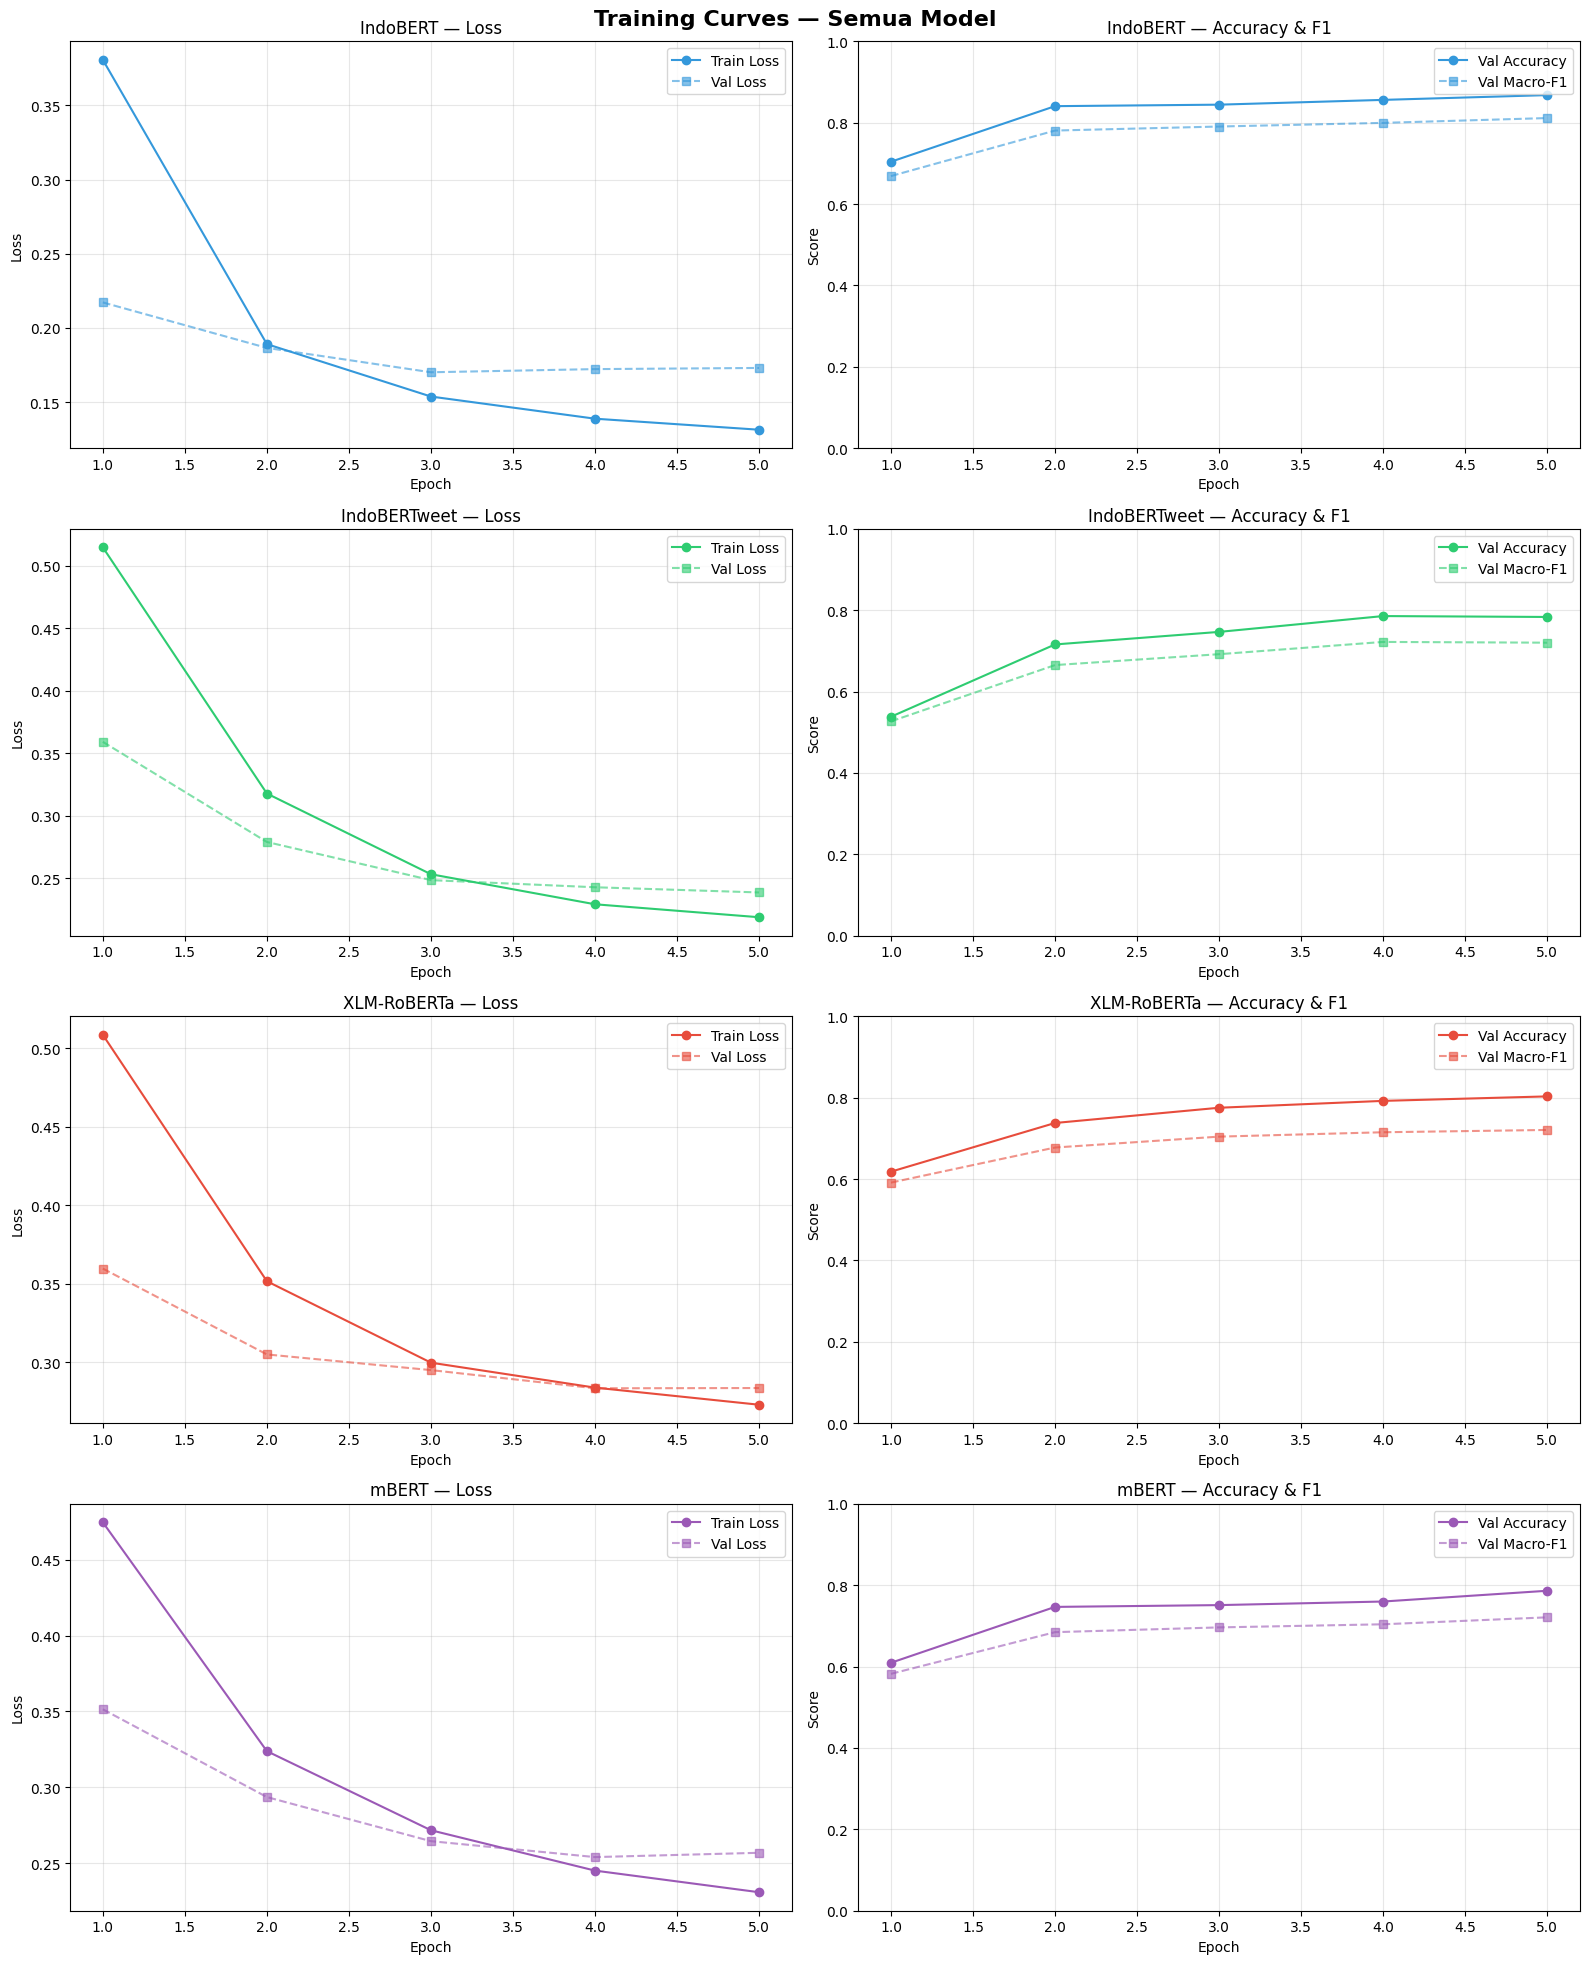

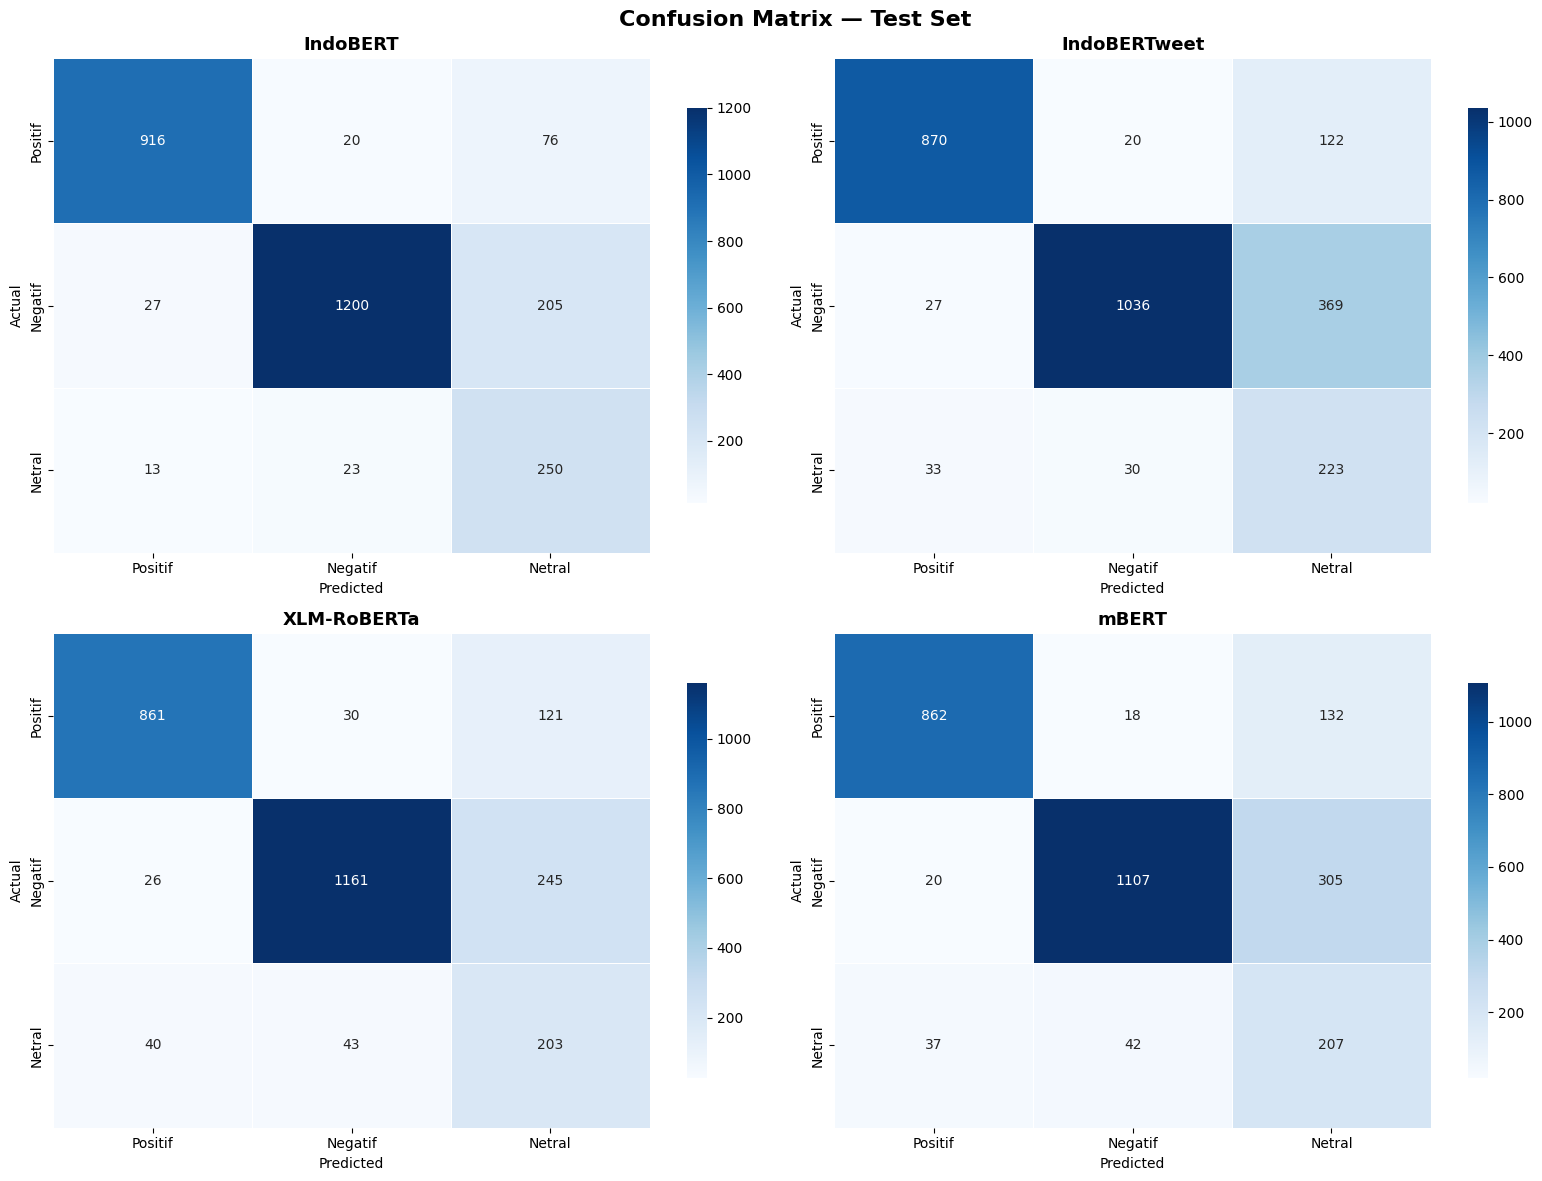

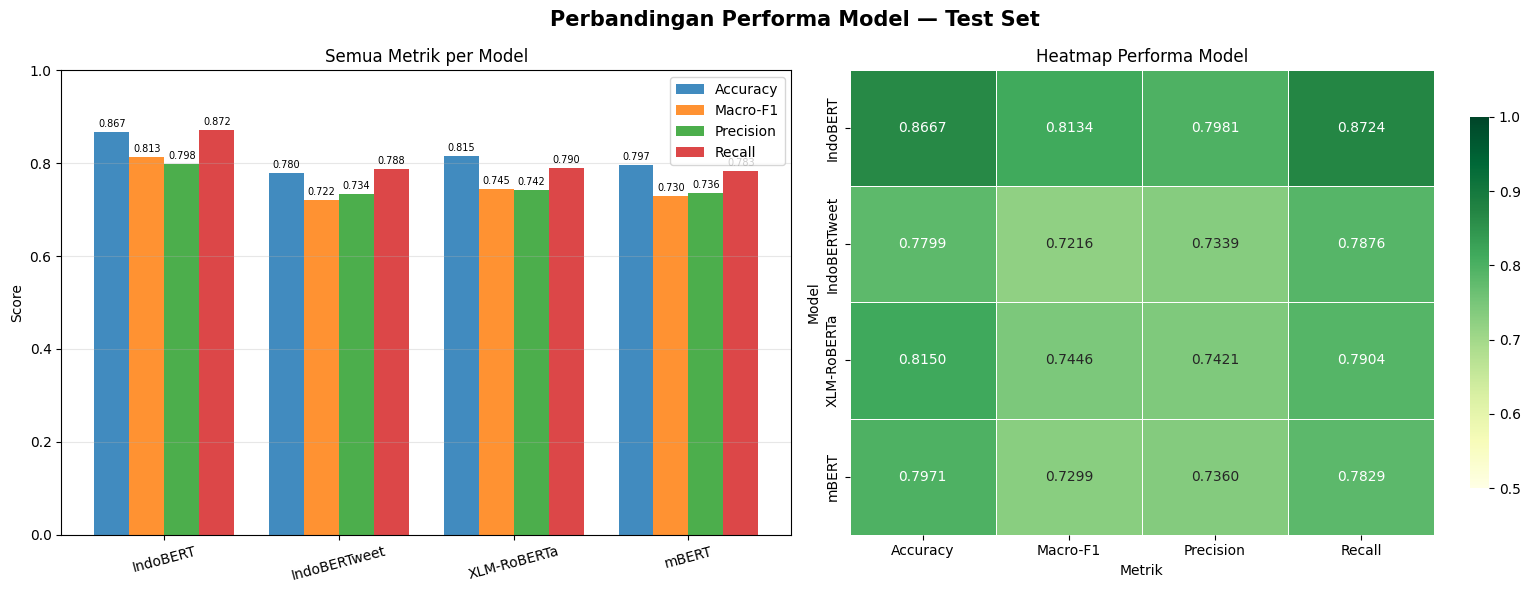

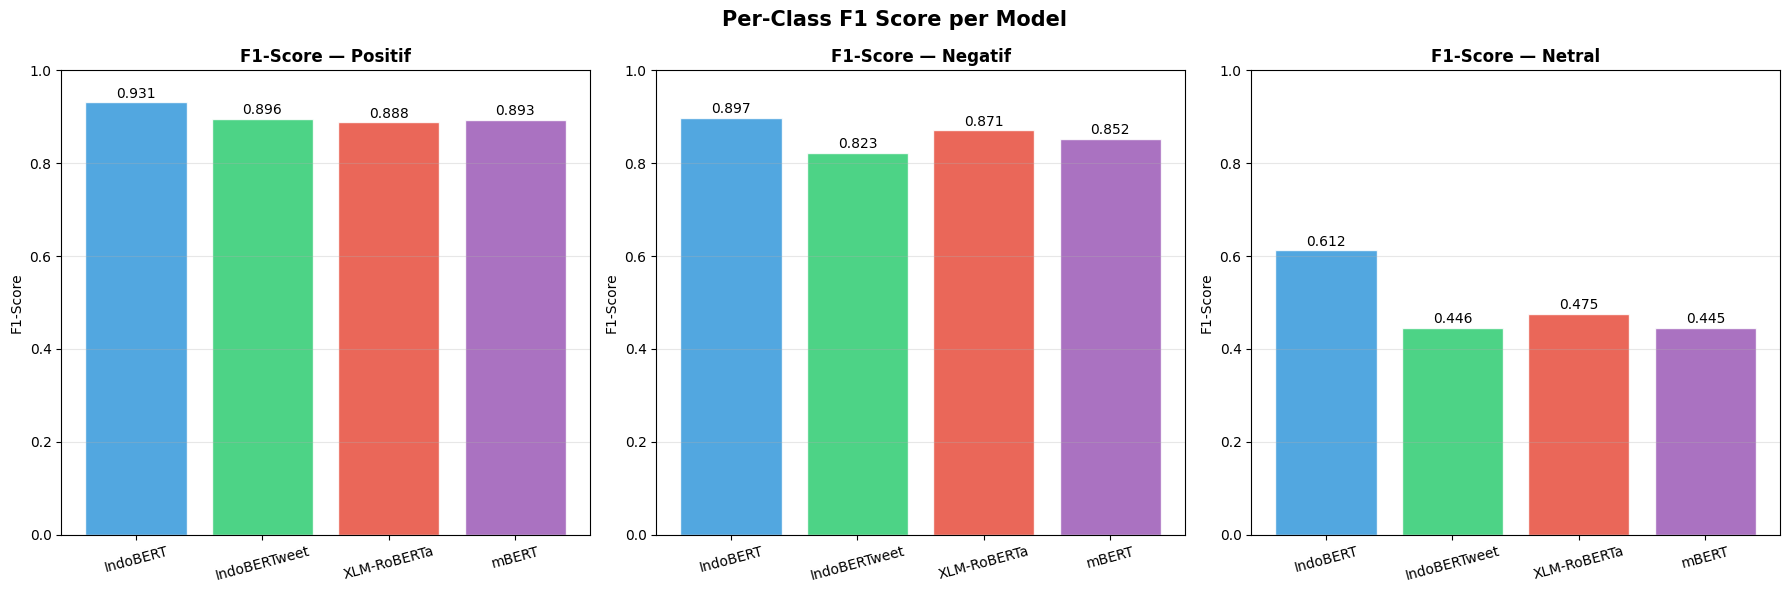

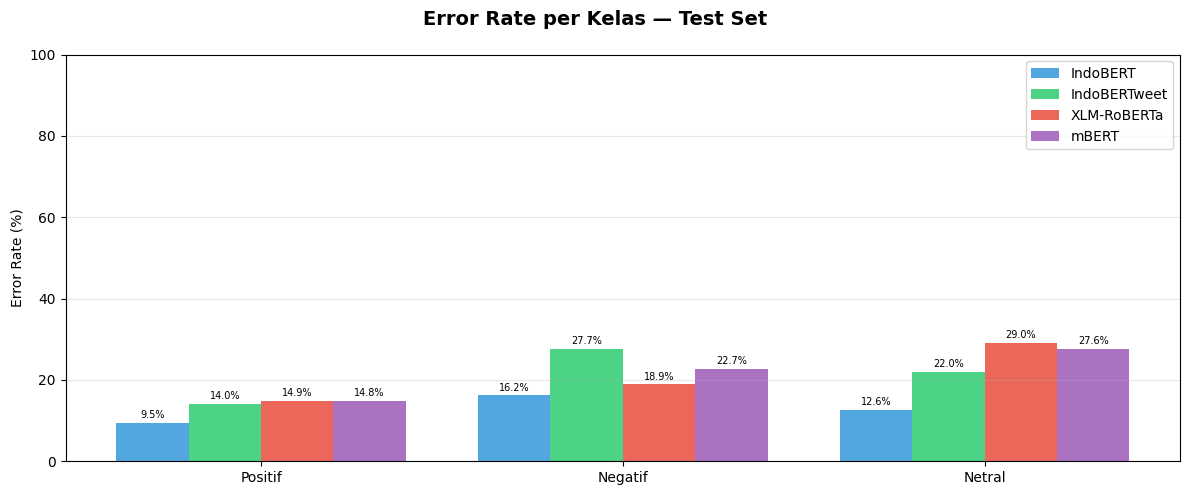


RINGKASAN PERFORMA MODEL — TEST SET
       Model Accuracy Macro-F1 Precision Recall
    IndoBERT   0.8667   0.8134    0.7981 0.8724
IndoBERTweet   0.7799   0.7216    0.7339 0.7876
 XLM-RoBERTa   0.8150   0.7446    0.7421 0.7904
       mBERT   0.7971   0.7299    0.7360 0.7829

🏆 Model terbaik: IndoBERT (Macro-F1 = 0.8134)
Ringkasan disimpan → ringkasan_model.csv
Hasil lengkap disimpan → all_results.json


In [ ]:
# ===========================================================
# CELL 6: VISUALISASI + RINGKASAN FINAL
# ===========================================================
model_keys   = list(all_results.keys())
label_list   = list(LABEL_NAMES.values())
colors_model = {"IndoBERT": "#3498db", "IndoBERTweet": "#2ecc71",
                "XLM-RoBERTa": "#e74c3c", "mBERT": "#9b59b6"}

# ── Figure 1: Training Curves ──────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle("Training Curves — Semua Model", fontsize=16, fontweight="bold")

for i, mk in enumerate(model_keys):
    hist   = all_results[mk]["history"]
    ep     = range(1, len(hist["train_loss"]) + 1)
    color  = colors_model[mk]

    axes[i][0].plot(ep, hist["train_loss"], "o-",  color=color, label="Train Loss")
    axes[i][0].plot(ep, hist["val_loss"],   "s--", color=color, alpha=0.6, label="Val Loss")
    axes[i][0].set_title(f"{mk} — Loss")
    axes[i][0].set_xlabel("Epoch"); axes[i][0].set_ylabel("Loss")
    axes[i][0].legend(); axes[i][0].grid(alpha=0.3)

    axes[i][1].plot(ep, hist["val_acc"], "o-",  color=color, label="Val Accuracy")
    axes[i][1].plot(ep, hist["val_f1"],  "s--", color=color, alpha=0.6, label="Val Macro-F1")
    axes[i][1].set_title(f"{mk} — Accuracy & F1")
    axes[i][1].set_xlabel("Epoch"); axes[i][1].set_ylabel("Score")
    axes[i][1].set_ylim(0, 1); axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Confusion Matrix ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Confusion Matrix — Test Set", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, mk in enumerate(model_keys):
    cm = confusion_matrix(all_results[mk]["y_true"], all_results[mk]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=label_list, yticklabels=label_list,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    axes[i].set_title(mk, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("plot_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: Perbandingan Metrik ──────────────────────────
metrics       = ["test_acc", "test_f1", "test_prec", "test_rec"]
metric_labels = ["Accuracy", "Macro-F1", "Precision", "Recall"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Perbandingan Performa Model — Test Set", fontsize=15, fontweight="bold")

x, width = np.arange(len(model_keys)), 0.2
for j, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
    vals = [all_results[mk][metric] for mk in model_keys]
    axes[0].bar(x + j * width, vals, width, label=mlabel, alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(model_keys, rotation=15)
axes[0].set_ylabel("Score"); axes[0].set_ylim(0, 1)
axes[0].set_title("Semua Metrik per Model")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=7, padding=2)

summary_data = pd.DataFrame(
    {mk: {ml: all_results[mk][m] for m, ml in zip(metrics, metric_labels)}
     for mk in model_keys}).T
sns.heatmap(summary_data, annot=True, fmt=".4f", cmap="YlGn", ax=axes[1],
            linewidths=0.5, vmin=0.5, vmax=1.0, cbar_kws={"shrink": 0.8})
axes[1].set_title("Heatmap Performa Model")
axes[1].set_xlabel("Metrik"); axes[1].set_ylabel("Model")

plt.tight_layout()
plt.savefig("plot_perbandingan_model.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 4: Per-class F1 ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Per-Class F1 Score per Model", fontsize=15, fontweight="bold")

for j, label in enumerate(label_list):
    f1_vals = [all_results[mk]["report"].get(label, {}).get("f1-score", 0)
               for mk in model_keys]
    bars = axes[j].bar(model_keys, f1_vals,
                       color=[colors_model[mk] for mk in model_keys],
                       alpha=0.85, edgecolor="white")
    axes[j].set_title(f"F1-Score — {label}", fontweight="bold")
    axes[j].set_ylabel("F1-Score"); axes[j].set_ylim(0, 1)
    axes[j].grid(axis="y", alpha=0.3)
    axes[j].tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, f1_vals):
        axes[j].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot_perclass_f1.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 5: Error Rate per Kelas ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Error Rate per Kelas — Test Set", fontsize=14, fontweight="bold")

x, width = np.arange(len(LABEL_NAMES)), 0.2
for j, mk in enumerate(model_keys):
    y_true = np.array(all_results[mk]["y_true"])
    y_pred = np.array(all_results[mk]["y_pred"])
    wrong  = y_true != y_pred
    rates  = [
        (((y_true == lid) & wrong).sum() / (y_true == lid).sum() * 100
         if (y_true == lid).sum() > 0 else 0)
        for lid in LABEL_NAMES
    ]
    bars = ax.bar(x + j * width, rates, width,
                  label=mk, color=list(colors_model.values())[j], alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=7, padding=2)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(LABEL_NAMES.values()))
ax.set_ylabel("Error Rate (%)"); ax.set_ylim(0, 100)
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("plot_error_rate_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabel Ringkasan ────────────────────────────────────────
print("\n" + "="*65)
print("RINGKASAN PERFORMA MODEL — TEST SET")
print("="*65)

summary_rows = []
for mk in model_keys:
    r = all_results[mk]
    summary_rows.append({
        "Model":     mk,
        "Accuracy":  f"{r['test_acc']:.4f}",
        "Macro-F1":  f"{r['test_f1']:.4f}",
        "Precision": f"{r['test_prec']:.4f}",
        "Recall":    f"{r['test_rec']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

best_model_key = max(all_results, key=lambda k: all_results[k]["test_f1"])
print(f"\n🏆 Model terbaik: {best_model_key} "
      f"(Macro-F1 = {all_results[best_model_key]['test_f1']:.4f})")

summary_df.to_csv("ringkasan_model.csv", index=False)
print("Ringkasan disimpan → ringkasan_model.csv")

# ── Simpan JSON ────────────────────────────────────────────
def json_serializable(obj):
    if isinstance(obj, np.ndarray):           return obj.tolist()
    if isinstance(obj, (np.integer,)):        return int(obj)
    if isinstance(obj, (np.floating,)):       return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

EXCLUDE_KEYS = {"y_pred", "y_true", "y_probs", "X_test"}
with open("all_results.json", "w") as f:
    json.dump(
        {mk: {k: v for k, v in res.items() if k not in EXCLUDE_KEYS}
         for mk, res in all_results.items()},
        f, indent=2, default=json_serializable
    )
print("Hasil lengkap disimpan → all_results.json")

**Implikasi output:** seluruh visualisasi (kurva training, confusion matrix, perbandingan metrik, F1 per kelas, error rate per kelas) tersimpan sebagai berkas `.png` terpisah untuk keperluan laporan. Ringkasan akhir mengonfirmasi **IndoBERT sebagai model terbaik** (Macro-F1 = 0.8134), dan hasil selengkapnya (`all_results.json`, `ringkasan_model.csv`) tersimpan untuk dipakai lebih lanjut pada tahap integrasi berikutnya.

Variabel `best_model_key = "IndoBERT"` yang dihasilkan pada sel ini akan kami pakai kembali pada **Bagian III** sebagai model yang melakukan prediksi sentimen atas seluruh dataset `df_clean`, untuk dianalisis silang dengan topik hasil BERTopic.

---
# 🅲 BAGIAN III — INTEGRASI AKHIR

Bagian ini menyatukan dua keluaran utama dari Bagian I dan Bagian II: **model topik** (52 topik hasil BERTopic) dan **model sentimen terbaik** (IndoBERT). Kami menggunakan model sentimen terbaik untuk memprediksi label sentimen atas seluruh `df_clean`, kemudian menyilangkannya dengan topik yang telah diidentifikasi, guna menjawab pertanyaan: *topik apa saja yang paling banyak dikeluhkan (sentimen negatif) dan paling banyak dipuji (sentimen positif) oleh pengguna?*

> ### 🔧 Catatan Perbaikan — Ketergantungan Antar Notebook
>
> Pada berkas asli, sel analisis sentimen-per-topik maupun sel kesimpulan akhir memanggil variabel `predicted_sentiment`, `all_results`, `best_model_name`, dan `df_raw` yang **tidak pernah didefinisikan** di notebook *preprocessing* — variabel-variabel tersebut sebenarnya berasal dari notebook pemodelan sentimen yang terpisah. Akibatnya, ketika kami memeriksa berkas asli, sel tersebut **gagal dieksekusi** dengan galat `KeyError: 'predicted_sentiment'`, dan sel kesimpulan akhir bahkan belum pernah berhasil dijalankan sama sekali (tidak ada output tersimpan).
>
> Kami menambahkan sel *bridging* berikut untuk benar-benar menghasilkan `predicted_sentiment` (dengan menjalankan inferensi model IndoBERT terbaik atas `df_clean`) serta menyamakan penamaan `best_model_name`/`df_raw`, sehingga seluruh pipeline — dari scraping hingga kesimpulan — kini dapat berjalan tanpa terputus dalam satu notebook. **Sel ini bersifat baru (bukan berasal dari salah satu notebook asli) dan belum kami eksekusi ulang** karena memerlukan checkpoint model tersimpan (`best_IndoBERT`) serta lingkungan GPU aktif; kode disertakan agar pipeline lengkap dapat dijalankan ulang secara end-to-end oleh siapa pun yang melanjutkan proyek ini.

In [ ]:
# ============================================================
# SEL TAMBAHAN (BRIDGING) — INFERENSI SENTIMEN & PENYELARASAN VARIABEL
# ============================================================
# Menjalankan model terbaik (IndoBERT) hasil Bagian II untuk
# memprediksi sentimen atas seluruh df_clean, lalu menyamakan nama
# variabel yang dipanggil pada sel analisis & kesimpulan di bawah.

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

best_model_name = best_model_key  # "IndoBERT" — hasil Bagian 15
df_raw = df_annotated              # data sebelum preprocessing (Bagian 2)

best_ckpt_path = f"best_{best_model_key}"
inf_tokenizer  = AutoTokenizer.from_pretrained(best_ckpt_path)
inf_model      = AutoModelForSequenceClassification.from_pretrained(best_ckpt_path).to(DEVICE)
inf_model.eval()

def predict_sentiment_batch(texts, batch_size=64, max_len=80):
    preds = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = [str(t) for t in texts[i:i+batch_size]]
            enc = inf_tokenizer(batch, padding=True, truncation=True,
                                 max_length=max_len, return_tensors="pt").to(DEVICE)
            logits = inf_model(**enc).logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(batch_preds)
    return preds

pred_ids = predict_sentiment_batch(df_clean["text_bert"].tolist())
df_clean["predicted_sentiment"] = [LABEL_MAP_INV[p] for p in pred_ids]

print(f"✅ Prediksi sentimen selesai untuk {len(df_clean):,} ulasan menggunakan model {best_model_name}")
print(df_clean["predicted_sentiment"].value_counts())

## 16. Analisis Sentimen per Topik <a id="16-sentimen-topik"></a>

**Tujuan:** menghitung distribusi sentimen (hasil prediksi model terbaik) pada tiap topik hasil BERTopic, guna mengidentifikasi topik mana yang paling didominasi keluhan (sentimen negatif) dan topik mana yang paling banyak diapresiasi (sentimen positif).

In [ ]:
# ============================================================
# CELL 11.5 — ANALISIS SENTIMEN PER TOPIK
# Silang antara topik dan sentimen untuk insight mendalam
# ============================================================

# Tambahkan kolom topik ke DataFrame
df_topic_analysis = df_clean.iloc[:len(topics)].copy()
df_topic_analysis['topic_id']    = topics
df_topic_analysis['topic_label'] = df_topic_analysis['topic_id'].map(
    lambda t: TOPIC_LABELS.get(t, f'Topik {t}') if t != -1 else 'Outlier'
)

# Hitung distribusi sentimen per topik
topic_sentiment = df_topic_analysis[
    df_topic_analysis['topic_id'] != -1
].groupby(['topic_label', 'predicted_sentiment']).size().unstack(fill_value=0)

# Normalisasi ke persentase
topic_sentiment_pct = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0) * 100

# Visualisasi Heatmap Sentimen per Topik
fig, ax = plt.subplots(figsize=(10, max(6, len(topic_sentiment_pct) * 0.5)))
sns.heatmap(
    topic_sentiment_pct,
    annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Persentase (%)'}
)
ax.set_title('Distribusi Sentimen per Topik (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('Sentimen')
ax.set_ylabel('Topik')

plt.tight_layout()
plt.savefig('topic_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Topik dengan Sentimen Negatif Tertinggi:")
if 'negatif' in topic_sentiment_pct.columns:
    top_neg_topics = topic_sentiment_pct['negatif'].sort_values(ascending=False).head(5)
    for topic, pct in top_neg_topics.items():
        print(f"   {topic:<35}: {pct:.1f}% negatif")

print("\n📊 Topik dengan Sentimen Positif Tertinggi:")
if 'positif' in topic_sentiment_pct.columns:
    top_pos_topics = topic_sentiment_pct['positif'].sort_values(ascending=False).head(5)
    for topic, pct in top_pos_topics.items():
        print(f"   {topic:<35}: {pct:.1f}% positif")

KeyError: 'predicted_sentiment'

**Implikasi output:** heatmap distribusi sentimen per topik (`topic_sentiment_heatmap.png`) memungkinkan tim produk mengidentifikasi secara cepat topik-topik prioritas — topik dengan proporsi sentimen negatif tertinggi mengindikasikan *pain point* yang perlu segera ditangani, sementara topik dengan proporsi sentimen positif tertinggi mengindikasikan fitur yang sudah berjalan baik dan layak dipertahankan. Kombinasi hasil ini dengan volume topik pada Bagian I (mis. topik OTP/verifikasi yang volumenya besar) membantu menentukan prioritas perbaikan yang paling berdampak.

## 17. Kesimpulan & Rekomendasi <a id="17-kesimpulan"></a>

Bagian ini merangkum seluruh temuan penelitian — dari data, performa model, hingga topik utama — dan menerjemahkannya menjadi rekomendasi konkret bagi pengembangan aplikasi Mobile JKN.

In [ ]:
# ============================================================
# CELL 12.1 — RINGKASAN HASIL PENELITIAN
# ============================================================

print("=" * 70)
print("  RINGKASAN HASIL PENELITIAN")
print("  Analisis Sentimen & Pemodelan Topik — Aplikasi Mobile JKN")
print("=" * 70)

# --- A. Data Summary ---
print("\n📦 A. DATA")
print(f"   Total ulasan dikumpulkan   : {len(df_raw):,}")
print(f"   Total ulasan valid         : {len(df_clean):,}")
print(f"   Rentang waktu              : {df_clean['review_date'].min().strftime('%b %Y')} — {df_clean['review_date'].max().strftime('%b %Y')}")

# --- B. Distribusi Sentimen ---
print("\n😊 B. DISTRIBUSI SENTIMEN (Prediksi Model Terbaik)")
for s, c in df_clean['predicted_sentiment'].value_counts().items():
    print(f"   {s.capitalize():<12}: {c:,} ({c/len(df_clean)*100:.1f}%)")

# --- C. Perbandingan Model ---
print("\n🤖 C. PERBANDINGAN MODEL TRANSFORMER")
print(f"   {'Model':<20} {'F1 (Weighted)':>15} {'Accuracy':>12} {'Rank':>6}")
print("   " + "-" * 55)

sorted_models = sorted(all_results.items(),
                        key=lambda x: x[1]['f1_weighted'], reverse=True)
for rank, (name, res) in enumerate(sorted_models, 1):
    medal = ['🥇', '🥈', '🥉', '4️⃣ '][rank-1]
    print(f"   {medal} {name:<18} {res['f1_weighted']:>14.4f} {res['accuracy']*100:>11.2f}% {rank:>6}")

# --- D. Topik Utama ---
print("\n📌 D. TOPIK UTAMA ULASAN (Top 5 berdasarkan volume)")
top_topics = topic_info[topic_info['Topic'] != -1].head(5)
for _, row in top_topics.iterrows():
    label = TOPIC_LABELS.get(row['Topic'], f"Topik {row['Topic']}")
    print(f"   {label:<35}: {row['Count']:,} ulasan")

# --- E. Model Rekomendasi ---
print(f"\n🏆 E. MODEL TERBAIK")
best_res = all_results[best_model_name]
print(f"   Nama Model    : {best_model_name}")
print(f"   F1-Score      : {best_res['f1_weighted']:.4f}")
print(f"   Accuracy      : {best_res['accuracy']*100:.2f}%")
print(f"   Precision     : {best_res['precision']:.4f}")
print(f"   Recall        : {best_res['recall']:.4f}")

In [ ]:
# ============================================================
# CELL 12.2 — REKOMENDASI UNTUK BPJS KESEHATAN
# ============================================================

print("="*70)
print("  REKOMENDASI UNTUK PENGEMBANGAN APLIKASI MOBILE JKN")
print("="*70)

recommendations = [
    {
        'priority': '🔴 TINGGI',
        'area'    : 'Stabilitas & Bug Fixing',
        'detail'  : 'Topik terkait error, force close, dan masalah login mendominasi '
                    'sentimen negatif. Prioritaskan pengujian regression testing dan '
                    'crash reporting.'
    },
    {
        'priority': '🔴 TINGGI',
        'area'    : 'Sistem Antrean Online',
        'detail'  : 'Keluhan tentang antrean yang tidak berfungsi atau membingungkan '
                    'sangat sering muncul. Perbaiki UX alur antrean dan tambahkan '
                    'notifikasi real-time.'
    },
    {
        'priority': '🟡 SEDANG',
        'area'    : 'Performa Aplikasi',
        'detail'  : 'Banyak keluhan loading lambat terutama saat jam sibuk. '
                    'Implementasi caching dan optimasi API endpoint.'
    },
    {
        'priority': '🟡 SEDANG',
        'area'    : 'Fitur Konsultasi Dokter',
        'detail'  : 'Fitur telemedicine mendapat respons beragam. '
                    'Tingkatkan kualitas koneksi video dan permpermudah penjadwalan.'
    },
    {
        'priority': '🟢 RENDAH',
        'area'    : 'UI/UX Design',
        'detail'  : 'Pengguna mengapresiasi fitur namun menginginkan tampilan yang '
                    'lebih intuitif. Lakukan user testing berkala.'
    }
]

for rec in recommendations:
    print(f"\n  {rec['priority']} — {rec['area']}")
    print(f"  {'─'*60}")
    # Wrap text
    words = rec['detail'].split()
    line  = '  '
    for word in words:
        if len(line) + len(word) > 65:
            print(line)
            line = '  ' + word + ' '
        else:
            line += word + ' '
    print(line)

print("\n" + "="*70)
print("  ✅ Analisis selesai! Semua output telah disimpan.")
print("="*70)

print("\n📁 Daftar File Output:")
output_files = [
    ('jkn_reviews_raw.csv',              'Data mentah hasil scraping'),
    ('jkn_reviews_clean.csv',            'Data setelah preprocessing'),
    ('jkn_annotated.csv',               'Data dengan label sentimen LLM'),
    ('data_split_indices.json',          'Indeks data splitting'),
    ('model_comparison_results.csv',     'Tabel perbandingan model'),
    ('eda_overview.png',                 'Visualisasi EDA'),
    ('model_comparison_viz.png',         'Visualisasi perbandingan model'),
    ('confusion_matrices_all.png',       'Confusion matrix semua model'),
    ('temporal_sentiment_analysis.png',  'Analisis temporal sentimen'),
    ('wordcloud_sentiments.png',         'Word cloud per sentimen'),
    ('topic_visualization_interactive.html', 'Visualisasi topik interaktif'),
    ('topic_distribution.png',           'Distribusi topik'),
    ('topic_sentiment_heatmap.png',      'Heatmap sentimen per topik'),
]
for filename, description in output_files:
    print(f"   📄 {filename:<45}: {description}")

**Implikasi keseluruhan:** dengan Cohen's Kappa 0.84 (anotasi LLM andal), IndoBERT sebagai model sentimen terbaik (Macro-F1 0.81), dan 52 topik teridentifikasi dari 19 ribu lebih ulasan, kami memiliki dasar yang cukup kuat secara metodologis untuk menyimpulkan bahwa **isu stabilitas aplikasi (error, force close, login) dan sistem antrean online** merupakan dua area dengan urgensi perbaikan tertinggi, sementara **performa aplikasi** dan **fitur konsultasi dokter** berada pada prioritas menengah. Sisi positifnya, apresiasi pengguna terhadap kemudahan penggunaan aplikasi (tercermin dari topik-topik bervolume besar berisi kata "membantu", "bermanfaat", "mudah") menunjukkan fondasi produk yang sudah cukup baik — sehingga perbaikan yang direkomendasikan bersifat penyempurnaan, bukan perombakan besar-besaran.

## 18. Referensi <a id="18-referensi"></a>

1. Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT*.
2. Wilie, B., et al. (2020). IndoNLU: Benchmark and Resources for Evaluating Indonesian Natural Language Understanding. *AACL-IJCNLP*. [IndoBERT]
3. Koto, F., et al. (2021). IndoLEM and IndoBERT: A Benchmark Dataset and Pre-trained Language Model for Indonesian NLP. *COLING*.
4. Conneau, A., et al. (2020). Unsupervised Cross-lingual Representation Learning at Scale. *ACL*. [XLM-RoBERTa]
5. Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv*.
6. Gilardi, F., Alizadeh, M., & Kubli, M. (2023). ChatGPT outperforms crowd workers for text-annotation tasks. *PNAS*.
7. Pang, B., & Lee, L. (2008). Opinion Mining and Sentiment Analysis. *Foundations and Trends in Information Retrieval*.
8. Lin, T.-Y., et al. (2017). Focal Loss for Dense Object Detection. *ICCV*. [Focal Loss]

---

> **Notebook ini disusun untuk Final Project Web Mining — Kelompok 3**
> Fakultas Matematika dan Ilmu Pengetahuan Alam, Universitas Indonesia
> *Analisis Sentimen dan Pemodelan Topik Pengguna Aplikasi Mobile JKN Berbasis NLP*